# **Latin Morphological Analyser**

Dataset used:  
https://github.com/syntacticus/syntacticus-treebank-data  
https://dev.syntacticus.org/development-guide/#lemma-part-of-speech-and-morphology


## **Set Up Environment**

In [ ]:
import os

### Install Latin BERT

Download the pre-trained Latin BERT model from the GitHub repository and define the path for the model to be used for fine-tuning.

In [ ]:
# clone latin bert repo
!git clone https://github.com/dbamman/latin-bert.git
%cd latin-bert

Cloning into 'latin-bert'...
remote: Enumerating objects: 154, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 154 (delta 4), reused 27 (delta 3), pack-reused 122 (from 1)
Receiving objects: 100% (154/154), 6.77 MiB | 8.16 MiB/s, done.
Resolving deltas: 100% (59/59), done.
/content/latin-bert


In [ ]:
# Download pre-trained BERT model for Latin
!./scripts/download.sh

--2026-04-02 08:30:00--  https://drive.usercontent.google.com/download?export=download&id=1Te_14UB-DZ8wYPhHGyDg7LadDTjNzpti&confirm=t&uuid=d7445489-608f-4c18-9ef2-6a3e45ce0373
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.101.132, 2607:f8b0:4023:c06::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.101.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 448020480 (427M) [application/octet-stream]
Saving to: ‘latin_bert.tar’

latin_bert.tar      100%[===================>] 427.27M  80.5MB/s    in 6.5s    

2026-04-02 08:30:07 (65.6 MB/s) - ‘latin_bert.tar’ saved [448020480/448020480]



In [ ]:
!ls -lah models/latin_bert | head

total 428M
drwxrwxr-x 2 1001 1001 4.0K Sep  4  2020 .
drwxr-xr-x 4 root root 4.0K Apr  2 08:30 ..
-rw-rw-r-- 1 1001 1001  503 Sep  4  2020 config.json
-rw-rw-r-- 1 1001 1001 428M Sep  4  2020 pytorch_model.bin
-rw-rw-r-- 1 1001 1001 217K Sep  4  2020 vocab.txt


In [ ]:
%cd ..

/content


In [ ]:
MODEL_PATH = os.path.join("latin-bert", "models", "latin_bert")

### Import Dependencies

1. Import all required libraries.
2. Mount Google Drive for storage access.
3. Setup HuggingFace access through token.
4. Define available device to be used.

In [ ]:
import sys
from dataclasses import dataclass, field
from typing import Optional, Union, Dict
import xml.etree.ElementTree as ET
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import transformers
from transformers import AutoTokenizer, AutoModel, PreTrainedModel, PreTrainedConfig, PreTrainedTokenizerBase, TrainingArguments, Trainer
# from transformers.modeling_outputs import TokenClassifierOutput
from transformers.modeling_outputs import ModelOutput
from datasets import Dataset
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

In [ ]:
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

In [ ]:
print(torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

True
Using device: cuda


## **Prepare Data**

### Load Dataset

Parse the XML file into sentences containing tokens.

In [ ]:
DATA_PATH = '/content/drive/MyDrive/FYP/latin-nt.xml'

In [ ]:
# define token and sentence classes

@dataclass
class Token:
  id: str
  form: Optional[str]
  lemma: Optional[str]
  pos: Optional[str]
  morphology: Optional[str]
  head_id: Optional[str]
  relation: Optional[str]

@dataclass
class Sentence:
  id: str
  tokens: list[Token] = field(default_factory=list)


In [ ]:
# parses all sentences in xml file, returns a list containing the sentences

def parse_proiel_xml(filepath: str) -> list[Sentence]:
  tree = ET.parse(filepath)
  root = tree.getroot()
  sentences = []

  for sentence_el in root.iter("sentence"):
    sent = Sentence(id=sentence_el.get("id"))
    for token_el in sentence_el.findall("token"):
      # Skip empty/trace tokens (no 'form')
      if token_el.get("form") is None:
        continue
      sent.tokens.append(Token(
          id=token_el.get("id"),
          form=token_el.get("form"),
          lemma=token_el.get("lemma"),
          pos=token_el.get("part-of-speech"),
          morphology=token_el.get("morphology"),
          head_id=token_el.get("head-id"),
          relation=token_el.get("relation"),
      ))
    if sent.tokens:
      sentences.append(sent)

  return sentences


In [ ]:
# load all sentences
sentences = parse_proiel_xml(DATA_PATH)
print(f"Loaded {len(sentences)} sentences")

Loaded 11851 sentences


In [ ]:
sentences[0]

Sentence(id='12667', tokens=[Token(id='250021', form='liber', lemma='liber', pos='Nb', morphology='-s---mn--i', head_id='851355', relation='xobj'), Token(id='250022', form='generationis', lemma='generatio', pos='Nb', morphology='-s---fg--i', head_id='250021', relation='atr'), Token(id='250023', form='Iesu', lemma='Iesus', pos='Ne', morphology='-s---mg--i', head_id='250022', relation='atr'), Token(id='250024', form='Christi', lemma='Christus', pos='Ne', morphology='-s---mg--i', head_id='250023', relation='apos'), Token(id='250025', form='filii', lemma='filius', pos='Nb', morphology='-s---mg--i', head_id='250023', relation='apos'), Token(id='250026', form='David', lemma='David', pos='Ne', morphology='---------n', head_id='250025', relation='atr'), Token(id='250027', form='filii', lemma='filius', pos='Nb', morphology='-s---mg--i', head_id='250025', relation='apos'), Token(id='250028', form='Abraham', lemma='Abraham', pos='Ne', morphology='---------n', head_id='250027', relation='atr')])

### Extract Labels from Data

**PROIEL morphology string decoder**  

The PROIEL `morphology` field is a 10-char positional string.  
Each character encodes one feature. Unused positions are "-".  
Reference: https://dev.syntacticus.org/development-guide/#lemma-part-of-speech-and-morphology

<br>

The final 2 characters ("strength" and "inflection") will be ignored.
*   no records contain "strength" info
*   "non-inflecting" tokens contain no other morphological information



In [ ]:
# mapping of the meaning of each char in the morphology string
MORPH_POSITIONS = {
    0: ("person", {"1": "1", "2": "2", "3": "3", "x": "Unc", "-": "None"}),
    1: ("number", {"s": "Sing", "p": "Plur", "d": "Dual", "x": "Unc", "-": "None"}),
    2: ("tense", {"p": "Pres", "i": "Imp", "r": "Perf", "l": "Plup", "f": "Fut",
                  "t": "FutPerf", "u": "Past", "s": "Res", "a": "Aorist", "x": "Unc", "-": "None"}), # "s" = "resultative"
    3: ("mood", {"i": "Ind", "s": "Sub", "m": "Imp", "o": "Opt", "n": "Inf", "p": "Part",
                 "d": "Ger", "g": "Gdv", "u": "Sup", "x": "Unc", "y": "FinUnsp", "e": "IndOrSub",
                 "f": "IndOrImp", "h": "SubOrImp", "t": "Fin", "-":"None"}),
    4: ("voice", {"a": "Act", "p": "Pass", "m": "Mid", "e": "MidOrPass", "x": "Unsp", "-": "None"}),
    5: ("gender", {"m": "Masc", "f": "Fem", "n": "Neut",
                   "p": "MascFem", "o": "MascNeut", "r": "FemNeut",
                   "q": "MascFemNeut", "x": "Unc", "-": "None"}),
    6: ("case", {"n": "Nom", "g": "Gen", "d": "Dat", "a": "Acc",
                 "b": "Abl", "v": "Voc", "l": "Loc", "o": "Obl",
                 "c": "GenDat", "e": "AccDat", "i": "Instr", "x": "Unc",
                 "z": "No", "-": "None"}),
    7: ("degree", {"p": "Pos", "c": "Comp", "s": "Sup", "x": "Unc", "z": "No", "-": "None"}),
    # 8: ("strength", {"w": "Weak", "s": "Strong", "t": "WkOrSt"}), # "t": "weak or strong"
    # 9: ("inflection", {"n": "NonInf", "i": "Inf"})                # non-inflecting, inflecting
}

# the order in which each feature appears in the morphology string
FEATURE_ORDER = ["person", "number", "tense", "mood", "voice",  "gender", "case",  "degree"]

In [ ]:
def decode_morphology(morph_str: str) -> dict:
    """
    Decode a PROIEL morphology string into a named feature dict.
    e.g. "3s---mn-" -> {"person":"3", "number":"Sing", ..., "case":"Nom", ...}
    Returns "None" for any absent/inapplicable position.
    """
    result = {feat: "None" for _, (feat, _) in MORPH_POSITIONS.items()}
    if not morph_str:
        return result
    for pos, (feat, mapping) in MORPH_POSITIONS.items():
        if pos < len(morph_str):
            result[feat] = mapping.get(morph_str[pos], "None")
    return result

**POS -> feature compatibility matrix**

Maps each specific PROIEL POS code to its applicable features, defines which of the morphological features are applicable per POS.

Order matches `FEATURE_ORDER`: person, number, tense, mood, voice, gender, case, degree

In [ ]:
# TODO: FIX TRUTH VALUES, CURRENTLY NOT ALL CORRECT

#          per    num    tense  mood   voice  gender case   degree
POS_FEATURE_MASK = {
    "A-": [False, True,  False, False, False, True,  True,  True  ],  # adjective
    "C-": [False, False, False, False, False, False, False, False ],  # conjunction
    "Df": [False, False, False, False, False, False, False, True  ],  # adverb
    "Dq": [False, False, False, False, False, False, False, False ],  # relative adverb
    "Du": [False, False, False, False, False, False, False, False ],  # interrogative adverb
    "F-": [False, False, False, False, False, False, False, False ],  # foreign word
    "G-": [False, False, False, False, False, False, False, False ],  # subjunction
    "I-": [False, False, False, False, False, False, False, False ],  # interjection
    "Ma": [False, True,  False, False, False, True,  True,  False ],  # cardinal numeral
    "Mo": [False, True,  False, False, False, True,  True,  False ],  # ordinal numeral
    "N-": [False, False, False, False, False, False, False, False ],  # infinitive marker
    "Nb": [False, True,  False, False, False, True,  True,  False ],  # common noun
    "Ne": [False, True,  False, False, False, True,  True,  False ],  # proper noun
    "Pc": [False, True,  False, False, False, True,  True,  False ],  # reciprocal pronoun
    "Pd": [False, True,  False, False, False, True,  True,  False ],  # demonstrative pronoun
    "Pi": [False, True,  False, False, False, True,  True,  False ],  # interrogative pronoun
    "Pk": [False, True,  False, False, False, True,  True,  False ],  # personal reflexive pronoun
    "Pp": [False, True,  False, False, False, True,  True,  False ],  # personal pronoun
    "Pr": [False, True,  False, False, False, True,  True,  False ],  # relative pronoun
    "Ps": [False, True,  False, False, False, True,  True,  False ],  # possessive pronoun
    "Pt": [False, True,  False, False, False, True,  True,  False ],  # possessive reflexive pronoun
    "Px": [False, True,  False, False, False, True,  True,  False ],  # indefinite pronoun
    "Py": [False, False, False, False, False, False, False, False ],  # quantifier
    "R-": [False, False, False, False, False, False, False, False ],  # preposition
    "S-": [False, False, False, False, False, False, False, False ],  # article
    "V-": [True,  True,  True,  True,  True,  False, False, False ],  # verb
    "X-": [False, False, False, False, False, False, False, False ]   # unassigned
}

**Build label vocabularies from data**

In [ ]:
def build_label_vocabs(sentences):
  """
  Scan all sentences and collect every observed value per feature.
  """
  vocabs = defaultdict(set)
  vocabs["pos"] = set()

  for sent in sentences:
    for tok in sent.tokens:
      if not tok.pos:
        continue
      vocabs["pos"].add(tok.pos)
      feats = decode_morphology(tok.morphology)
      for feat, val in feats.items():
        vocabs[feat].add(val)

  # Build label2id / id2label dicts; keep "None" last in each vocab
  label2id_all, id2label_all = {}, {}
  for feat, vals in vocabs.items():
    sorted_vals = sorted(v for v in vals if v != "None")
    if "None" in vals:
      sorted_vals.append("None")
    label2id_all[feat] = {v: i for i, v in enumerate(sorted_vals)}
    id2label_all[feat] = {i: v for v, i in label2id_all[feat].items()}

  return label2id_all, id2label_all

In [ ]:
# Build label vocabularies from data.
label2id_all, id2label_all = build_label_vocabs(sentences)

ALL_FEATS = ["pos"] + FEATURE_ORDER

# Quick summary
for feat in ALL_FEATS:
  print(f"{feat:10s} ({len(label2id_all[feat])} labels): {list(label2id_all[feat].keys())}")

pos        (23 labels): ['A-', 'C-', 'Df', 'Dq', 'Du', 'F-', 'G-', 'I-', 'Ma', 'Mo', 'Nb', 'Ne', 'Pc', 'Pd', 'Pi', 'Pk', 'Pp', 'Pr', 'Ps', 'Pt', 'Px', 'R-', 'V-']
person     (4 labels): ['1', '2', '3', 'None']
number     (3 labels): ['Plur', 'Sing', 'None']
tense      (7 labels): ['Fut', 'FutPerf', 'Imp', 'Perf', 'Plup', 'Pres', 'None']
mood       (9 labels): ['Gdv', 'Ger', 'Imp', 'Ind', 'Inf', 'Part', 'Sub', 'Sup', 'None']
voice      (3 labels): ['Act', 'Pass', 'None']
gender     (8 labels): ['Fem', 'FemNeut', 'Masc', 'MascFem', 'MascFemNeut', 'MascNeut', 'Neut', 'None']
case       (7 labels): ['Abl', 'Acc', 'Dat', 'Gen', 'Nom', 'Voc', 'None']
degree     (4 labels): ['Comp', 'Pos', 'Sup', 'None']


**Convert sentences to multi-label records**

In [ ]:
IGNORE_INDEX = -100

def to_multilabel_records(sentences, label2id_all):
    records = []
    for sent in sentences:
        tokens, pos_labels = [], []
        feat_labels = {feat: [] for feat in FEATURE_ORDER}
        valid = True

        for tok in sent.tokens:
            if not tok.pos or tok.pos not in label2id_all["pos"]:
                valid = False
                break
            tokens.append(tok.form.lower())
            pos_labels.append(label2id_all["pos"][tok.pos])

            feats = decode_morphology(tok.morphology)
            for feat in FEATURE_ORDER:
                feat_labels[feat].append(label2id_all[feat][feats[feat]])

        if valid and len(tokens) == len(pos_labels):
            record = {"tokens": tokens, "labels_pos": pos_labels}
            for feat in FEATURE_ORDER:
                record[f"labels_{feat}"] = feat_labels[feat]
            records.append(record)

    return records

In [ ]:
multilabel_records = to_multilabel_records(sentences, label2id_all)
print(f"Total records: {len(multilabel_records)}")

Total records: 11851


### Split into Train/Test/Validation Sets

In [ ]:
# 70% train, 15% test, 15% val
multi_dataset = Dataset.from_list(multilabel_records)
multi_dataset = multi_dataset.train_test_split(test_size=0.3, seed=42)
train_ds = multi_dataset["train"]
test_val = multi_dataset["test"].train_test_split(test_size=0.5, seed=42)
test_ds  = test_val["train"]
val_ds   = test_val["test"]

In [ ]:
train_ds[0]

{'tokens': ['domine', 'bonum', 'est', 'nos', 'hic', 'esse'],
 'labels_pos': [10, 0, 22, 16, 2, 22],
 'labels_person': [3, 3, 2, 0, 3, 3],
 'labels_number': [1, 1, 1, 0, 2, 2],
 'labels_tense': [6, 6, 5, 6, 6, 5],
 'labels_mood': [8, 8, 3, 8, 8, 4],
 'labels_voice': [2, 2, 0, 2, 2, 0],
 'labels_gender': [2, 6, 7, 2, 7, 7],
 'labels_case': [5, 4, 6, 1, 6, 6],
 'labels_degree': [3, 1, 3, 3, 3, 3]}

In [ ]:
print(f"{len(train_ds)} train | {len(val_ds)} val | {len(test_ds)} test")

8295 train | 1778 val | 1778 test


## **Tokenization**

### Load Tokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

In [ ]:
type(tokenizer)

transformers.models.bert.tokenization_bert.BertTokenizer

In [ ]:
# tokenize function
def tokenize_and_align_multilabels(batch):
    tokenized = tokenizer(
        batch["tokens"],
        truncation=True,
        is_split_into_words=True,
        padding="max_length",
        max_length=128,
    )

    all_aligned = {feat: [] for feat in ALL_FEATS}

    for i in range(len(batch["tokens"])):
        word_ids = tokenized.word_ids(batch_index=i)
        prev_wid = None
        per_feat = {feat: [] for feat in ALL_FEATS}

        for wid in word_ids:
            is_first = (wid is not None and wid != prev_wid)
            for feat in ALL_FEATS:
                word_labels = batch[f"labels_{feat}"][i]
                if wid is None:
                    per_feat[feat].append(IGNORE_INDEX)
                elif is_first:
                    per_feat[feat].append(word_labels[wid])
                else:
                    per_feat[feat].append(IGNORE_INDEX)
            prev_wid = wid

        for feat in ALL_FEATS:
            all_aligned[feat].append(per_feat[feat])

    for feat in ALL_FEATS:
        tokenized[f"labels_{feat}"] = all_aligned[feat]

    return tokenized

### Tokenize Dataset

In [ ]:
# Columns to drop — "tokens" (strings) and original word-level label lists
# The aligned labels_{feat} overwrite the word-level ones with the same key,
# but "tokens" has no counterpart to overwrite it, so it must be removed.
cols_to_remove = ["tokens"] + [f"labels_{feat}" for feat in ALL_FEATS]

In [ ]:
train_ds = train_ds.map(tokenize_and_align_multilabels, batched=True, remove_columns=cols_to_remove)
val_ds = val_ds.map(tokenize_and_align_multilabels,   batched=True, remove_columns=cols_to_remove)
test_ds = test_ds.map(tokenize_and_align_multilabels,  batched=True, remove_columns=cols_to_remove)

Map:   0%|          | 0/8295 [00:00<?, ? examples/s]

Map:   0%|          | 0/1778 [00:00<?, ? examples/s]

Map:   0%|          | 0/1778 [00:00<?, ? examples/s]

In [ ]:
# Verify only tensor-compatible columns remain
print(train_ds.column_names)
# Expected: ['input_ids', 'attention_mask', 'token_type_ids',
#            'labels_pos', 'labels_person', ..., 'labels_degree']

['labels_pos', 'labels_person', 'labels_number', 'labels_tense', 'labels_mood', 'labels_voice', 'labels_gender', 'labels_case', 'labels_degree', 'input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
print(train_ds[0])

{'labels_pos': [-100, 10, 0, 22, 16, 2, 22, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100], 'labels_person': [-100, 3, 3, 2, 0, 3, 3, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -

## **Define Model**

**POS-feature compatibility mask tensor**

In [ ]:
def build_pos_mask_tensor(label2id_pos, device):
    """
    Build a (num_pos, num_features) bool tensor directly from POS_FEATURE_MASK.
    Any POS code not listed in POS_FEATURE_MASK gets all-False (no features).
    Unknown codes are reported so you can add them explicitly.
    """
    num_pos   = len(label2id_pos)
    num_feats = len(FEATURE_ORDER)
    mask      = torch.zeros(num_pos, num_feats, dtype=torch.bool)

    for pos_code, pos_idx in label2id_pos.items():
        if pos_code in POS_FEATURE_MASK:
            for fi, applicable in enumerate(POS_FEATURE_MASK[pos_code]):
                mask[pos_idx, fi] = applicable
        else:
            # Surface any unmapped codes immediately rather than silently
            # treating them as all-False
            print(f"WARNING: POS code '{pos_code}' not in POS_FEATURE_MASK "
                  f"— all features will be masked off for this tag. "
                  f"Add it explicitly.")

    return mask.to(device)

In [ ]:
pos_mask_tensor = build_pos_mask_tensor(label2id_all["pos"], device)

In [ ]:
# Sanity checks — print the mask for every code in your corpus
print(f"{'Code':<6} {'Features active':}")
for pos_code, pos_idx in sorted(label2id_all["pos"].items()):
    active = [f for fi, f in enumerate(FEATURE_ORDER)
              if pos_mask_tensor[pos_idx, fi].item()]
    print(f"  {pos_code:<6} {active if active else '—'}")

Code   Features active
  A-     ['number', 'gender', 'case', 'degree']
  C-     —
  Df     ['degree']
  Dq     —
  Du     —
  F-     —
  G-     —
  I-     —
  Ma     ['number', 'gender', 'case']
  Mo     ['number', 'gender', 'case']
  Nb     ['number', 'gender', 'case']
  Ne     ['number', 'gender', 'case']
  Pc     ['number', 'gender', 'case']
  Pd     ['number', 'gender', 'case']
  Pi     ['number', 'gender', 'case']
  Pk     ['number', 'gender', 'case']
  Pp     ['number', 'gender', 'case']
  Pr     ['number', 'gender', 'case']
  Ps     ['number', 'gender', 'case']
  Pt     ['number', 'gender', 'case']
  Px     ['number', 'gender', 'case']
  R-     —
  V-     ['person', 'number', 'tense', 'mood', 'voice']


**Multi-head model definition**

In [ ]:
# create the custom configuration class
# inherits from pretrainedconfig class
# 4 additional member variables

class LatinMorphologicalAnalyserConfig(PreTrainedConfig):
  '''
  '''
  model_type = "latin_morphological_analyser"

  def __init__(self, bert_model_path="", num_labels_per_feat=None, pos_embed_dim=64, dropout=0.1, label2id_all=None, id2label_all=None, pos_feature_mask=None, initializer_range=0.02, **kwargs):
    super().__init__(**kwargs)
    self.bert_model_path = bert_model_path                # path to the pretrained latin bert model
    self.num_labels_per_feat = num_labels_per_feat or {}
    self.pos_embed_dim = pos_embed_dim
    self.dropout = dropout                                # dropout rate
    self.label2id_all = label2id_all or {}
    self.id2label_all = id2label_all or {}
    self.pos_feature_mask = pos_feature_mask or {}
    self.initializer_range = initializer_range


In [ ]:
# A small two-layer MLP for classifying a single morphological feature.
# It receives both the raw BERT hidden state and a pos_context vector
# representing which POS the model currently thinks this token is.
# The concatenation [bert_repr, pos_context] lets the feature head condition its prediction on the POS
# — e.g. the tense head can look at POS confidence to know whether it should be predicting tense at all.

# a morphological feature head

class POSConditionedHead(nn.Module):
    """
    A 2-layer classification head that concatenates the BERT token
    embedding with a soft POS context vector before classifying.
    """
    def __init__(self, bert_hidden, pos_embed_dim, num_labels, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(bert_hidden + pos_embed_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_labels),
        )

    def forward(self, bert_repr, pos_context):
        # bert_repr  : (..., bert_hidden)
        # pos_context: (..., pos_embed_dim)
        return self.net(torch.cat([bert_repr, pos_context], dim=-1))

In [ ]:
# define a custom model output dataclass
# subclass of ModelOutput
# the data structure containing all the information returned by the model

@dataclass
class MorphologicalAnalyserOutput(ModelOutput):
  """
  Outputs of the morphological analyser model.
  """
  loss: torch.FloatTensor | None = None
  logits: torch.FloatTensor | None = None # POS logits
  feature_logits: Dict[str, torch.FloatTensor] | None = None
  hidden_states: tuple[torch.FloatTensor, ...] | None = None # proper BERT hidden states
  attentions: tuple[torch.FloatTensor, ...] | None = None

In [ ]:
# create the top level model

class LatinMorphologicalAnalyser(PreTrainedModel):
  '''
  '''
  config_class = LatinMorphologicalAnalyserConfig
  base_model_prefix = "bert"##

  def __init__(self, config):
    super().__init__(config)

    self.bert = AutoModel.from_pretrained(config.bert_model_path) # load the pretrained latin bert weihhts
    # self.bert = AutoModel.from_pretrained(config.bert_model_path, local_files_only=True) # treat it as a local path, never hit the Hub

    hidden = self.bert.config.hidden_size # hidden layer number of input neruons

    # Reconstruct these from config instead of accepting as arguments
    self.label2id_all  = config.label2id_all
    self.id2label_all  = {feat: {int(k): v for k, v in d.items()} for feat, d in config.id2label_all.items()} # convert keys to int
    self.feature_order = FEATURE_ORDER

    # Rebuild the pos_mask tensor from config and register it as a buffer
    pos_mask = self._build_pos_mask(config)         # shape -> (num_pos, num_feats)
    self.register_buffer("pos_mask", pos_mask)

    num_pos = config.num_labels_per_feat["pos"]
    pos_embed_dim = config.pos_embed_dim
    dropout = config.dropout

    # creating the new layers:

    # POS head (no POS conditioning - feeds raw BERT repr)
    self.pos_dropout = nn.Dropout(dropout)     # dropiut layer
    self.pos_head = nn.Linear(hidden, num_pos) # a single linear layer mapping BERT's hidden states to POS logits

    # Soft POS conditioning embedding
    # pos_probs (batch, seq, num_pos) @ pos_embedding.weight (num_pos, dim)
    # → pos_context (batch, seq, dim)   [fully differentiable]
    self.pos_embedding = nn.Embedding(num_pos, pos_embed_dim)

    # One conditioned head per morphological feature
    self.feature_heads = nn.ModuleDict({
        feat: POSConditionedHead(
            bert_hidden   = hidden,
            pos_embed_dim = pos_embed_dim,
            num_labels    = config.num_labels_per_feat[feat],
            dropout       = dropout,
        )
        for feat in FEATURE_ORDER
    })

    self.post_init()


  def _build_pos_mask(self, config):
    label2id_pos = config.label2id_all["pos"]
    num_pos = len(label2id_pos)
    num_feats = len(FEATURE_ORDER)
    mask = torch.zeros(num_pos, num_feats, dtype=torch.bool)

    for pos_code, pos_idx in label2id_pos.items():
      if pos_code in config.pos_feature_mask:
        for fi, applicable in enumerate(config.pos_feature_mask[pos_code]):
          mask[pos_idx, fi] = applicable

    return mask

  def _init_weights(self, module):
    # initialise the weights and biases for new layers added
    if isinstance(module, nn.Linear):
      module.weight.data.normal_(mean=0.0, std=self.config.initializer_range)
      if module.bias is not None:
        module.bias.data.zero_()
    elif isinstance(module, nn.Embedding):
      module.weight.data.normal_(mean=0.0, std=self.config.initializer_range)


  def forward(self, input_ids=None, attention_mask=None, labels_pos=None, labels_person=None, labels_number=None, labels_tense=None, labels_mood=None, labels_voice=None, labels_gender=None, labels_case=None, labels_degree=None, **kwargs):
    # forward pass thru the model

    # ── 1. BERT ────────────────────────────────────────────────────
    # pass inputs through the pretrained latin bert
    bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
    x = self.pos_dropout(bert_out.last_hidden_state)  # (B, T, H)

    # ── 2. POS classification ──────────────────────────────────────
    pos_logits = self.pos_head(x)                      # (B, T, num_pos)
    pos_probs  = torch.softmax(pos_logits, dim=-1)     # (B, T, num_pos)

    # ── 3. Soft POS context (differentiable weighted sum) ──────────
    pos_context = pos_probs @ self.pos_embedding.weight  # (B, T, pos_dim)

    # ── 4. Feature heads ───────────────────────────────────────────
    label_tensors = {
        "person": labels_person, "number": labels_number,
        "tense":  labels_tense,  "mood":   labels_mood,
        "voice":  labels_voice,  "gender": labels_gender,
        "case":   labels_case,   "degree": labels_degree,
    }
    feature_logits = {
        feat: head(x, pos_context)
        for feat, head in self.feature_heads.items()
    }   # each: (B, T, num_labels_for_feat)

    # ── 5. Loss ────────────────────────────────────────────────────
    loss = None
    if labels_pos is not None:
      import torch.nn.functional as F

      # POS loss — always computed for all valid tokens
      pos_loss = F.cross_entropy(
          pos_logits.view(-1, pos_logits.size(-1)),
          labels_pos.view(-1),
          ignore_index=IGNORE_INDEX,
      )
      loss = pos_loss

      for feat_idx, feat in enumerate(FEATURE_ORDER):
        feat_labels = label_tensors[feat]
        if feat_labels is None:
            continue

        # Build a boolean mask: which tokens have this feature applicable?
        #   - token must not be padding (labels_pos != IGNORE_INDEX)
        #   - token's TRUE POS must have this feature active
        valid      = labels_pos != IGNORE_INDEX          # (B, T)
        pos_clamp  = labels_pos.clone()
        pos_clamp[~valid] = 0                            # safe index
        applicable = self.pos_mask[pos_clamp, feat_idx]  # (B, T) bool
        applicable = applicable & valid

        if applicable.any():
          feat_loss = F.cross_entropy(
              feature_logits[feat][applicable],   # (N, num_labels)
              feat_labels[applicable],            # (N,)
              ignore_index=IGNORE_INDEX,
          )
          loss = loss + feat_loss

    # Return pos_logits as primary logits (Trainer compatibility).
    # Stash feature_logits in hidden_states for custom inference.
    # return TokenClassifierOutput(
    #     loss=loss,
    #     logits=pos_logits,
    #     hidden_states=(feature_logits,),
    # )

    return MorphologicalAnalyserOutput(
        loss=loss,
        logits=pos_logits,
        feature_logits=feature_logits,
    )


## **Train Model**

In [ ]:
# Define a path for a dummy file to satisfy transformers' internal checks
dummy_file_path = 'latin_morphological_analyser_model.py'

# Create the dummy file if it doesn't exist
if not os.path.exists(dummy_file_path):
    with open(dummy_file_path, 'w') as f:
        f.write("# Dummy file for __main__ module in Colab to satisfy transformers library checks\n")

sys.modules['__main__'].__file__ = dummy_file_path

### Load Model

In [ ]:
num_labels_per_feat = {feat: len(vocab) for feat, vocab in label2id_all.items()}

morph_config = LatinMorphologicalAnalyserConfig(
    bert_model_path    = MODEL_PATH,
    num_labels_per_feat = num_labels_per_feat,
    label2id_all        = label2id_all,
    id2label_all = {feat: {str(k): v for k, v in d.items()} for feat, d in id2label_all.items()}, # convert int keys to str for JSON
    pos_feature_mask    = POS_FEATURE_MASK,
    pos_embed_dim      = 64,
    dropout            = 0.1,
)

model_multi = LatinMorphologicalAnalyser(morph_config).to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: latin-bert/models/latin_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
total_params = sum(p.numel() for p in model_multi.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Trainable parameters: 113,045,252


In [ ]:
print(model_multi)

LatinMorphologicalAnalyser(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32900, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

### Define Custom Data Collator

In [ ]:
@dataclass
class MultiLabelDataCollator:
    tokenizer:           PreTrainedTokenizerBase
    padding:             Union[bool, str] = True
    max_length:          Optional[int]   = None
    label_pad_token_id:  int             = IGNORE_INDEX
    feat_names:          list            = None

    def __call__(self, features):
        label_keys = [f"labels_{f}" for f in self.feat_names]

        labels_dict = {k: [f[k] for f in features] for k in label_keys}
        stripped    = [{k: v for k, v in f.items()
                        if k not in label_keys} for f in features]

        batch   = self.tokenizer.pad(
            stripped, padding=self.padding,
            max_length=self.max_length, return_tensors="pt",
        )
        seq_len = batch["input_ids"].shape[1]

        for key, seqs in labels_dict.items():
            padded = [
                # Convert to list first — seq may be a tensor when
                # the dataset is in torch format (e.g. inside a DataLoader)
                list(seq) + [self.label_pad_token_id] * (seq_len - len(seq))
                for seq in seqs
            ]
            batch[key] = torch.tensor(padded, dtype=torch.long)

        return batch

In [ ]:
data_collator_multi = MultiLabelDataCollator(
    tokenizer  = tokenizer,
    feat_names = ALL_FEATS,
)

### Compute Metrics Function

POS accuracy shown during training

In [ ]:
def compute_metrics_pos(eval_pred):
    """
    Trainer passes EvalPrediction(predictions, label_ids).
    predictions will be pos_logits and label_ids will be labels_pos.
    Compute POS-level metrics for monitoring.
    """
    # If eval_pred.predictions is a tuple, take the first element (pos_logits)
    if isinstance(eval_pred.predictions, tuple):
        logits = eval_pred.predictions[0]
    else:
        logits = eval_pred.predictions

    # If eval_pred.label_ids is a tuple, take the first element (labels_pos)
    # as compute_metrics_pos is specifically for POS.
    if isinstance(eval_pred.label_ids, tuple):
        labels_pos = eval_pred.label_ids[0]
    else:
        labels_pos = eval_pred.label_ids

    preds_pos = np.argmax(logits, axis=-1)

    true_flat, pred_flat = [], []
    for pred_row, label_row in zip(preds_pos, labels_pos):
            for p, l in zip(pred_row, label_row):
                if l != IGNORE_INDEX:
                    true_flat.append(l)
                    pred_flat.append(p)

    report = classification_report(
        true_flat, pred_flat,
        labels      = list(range(len(id2label_all["pos"]))),
        target_names= [id2label_all["pos"][i]
                       for i in range(len(id2label_all["pos"]))],
        output_dict = True,
        zero_division = 0,
    )
    return {
        "pos_accuracy":    report["accuracy"],
        "pos_f1_macro":    report["macro avg"]["f1-score"],
        "pos_f1_weighted": report["weighted avg"]["f1-score"],
    }

### Phase 1

In [ ]:
for param in model_multi.bert.parameters():
    param.requires_grad = False

In [ ]:
args_phase1 = TrainingArguments(
    output_dir                 = "amysp/latin-morphological-analyser-multihead",
    push_to_hub                = True,
    hub_strategy               = "every_save",
    hub_private_repo           = True,
    eval_strategy              = "epoch",
    save_strategy              = "epoch",
    learning_rate              = 1e-3,   # higher LR - only heads training
    per_device_train_batch_size= 32,
    per_device_eval_batch_size = 32,
    num_train_epochs           = 2,
    weight_decay               = 0.01,
    load_best_model_at_end     = True,
    save_total_limit           = 1,
    metric_for_best_model      = "pos_accuracy",
    greater_is_better          = True,
    report_to                  = "none",
    fp16                       = True,
)

In [ ]:
trainer_p1 = Trainer(
    model           = model_multi,
    args            = args_phase1,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    data_collator   = data_collator_multi,
    compute_metrics = compute_metrics_pos,
)

In [ ]:
trainer_p1.train()

Epoch,Training Loss,Validation Loss,Pos Accuracy,Pos F1 Macro,Pos F1 Weighted
1,No log,6.795495,0.667784,0.451035,0.640223
2,7.394213,6.556365,0.678978,0.486865,0.654235


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=520, training_loss=7.364666894766001, metrics={'train_runtime': 101.644, 'train_samples_per_second': 163.217, 'train_steps_per_second': 5.116, 'total_flos': 1113342356367360.0, 'train_loss': 7.364666894766001, 'epoch': 2.0})

### Phase 2

In [ ]:
for param in model_multi.bert.parameters():
    param.requires_grad = True

In [ ]:
args_phase2 = TrainingArguments(
    output_dir                 = "amysp/latin-morphological-analyser-multihead",
    push_to_hub                = True,
    hub_strategy               = "every_save",
    hub_private_repo           = True,
    eval_strategy              = "epoch",
    save_strategy              = "epoch",
    learning_rate              = 2e-5,
    per_device_train_batch_size= 32,
    per_device_eval_batch_size = 32,
    num_train_epochs           = 5,
    weight_decay               = 0.01,
    load_best_model_at_end     = True,
    save_total_limit           = 1,
    metric_for_best_model      = "pos_accuracy",
    greater_is_better          = True,
    report_to                  = "none",
    fp16                       = True,
)

In [ ]:
trainer_p2 = Trainer(
    model           = model_multi,
    args            = args_phase2,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    data_collator   = data_collator_multi,
    compute_metrics = compute_metrics_pos,
    callbacks       = [transformers.EarlyStoppingCallback(early_stopping_patience=3)],
)

In [ ]:
trainer_p2.train()

Epoch,Training Loss,Validation Loss,Pos Accuracy,Pos F1 Macro,Pos F1 Weighted
1,No log,5.519942,0.734108,0.562876,0.718842
2,5.543131,5.358041,0.742967,0.579434,0.730234
3,5.543131,5.311630,0.746738,0.587324,0.735711
4,4.968763,5.297147,0.749192,0.590908,0.738171
5,4.968763,5.295169,0.749671,0.593628,0.738906


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1300, training_loss=5.133769249549279, metrics={'train_runtime': 626.6181, 'train_samples_per_second': 66.189, 'train_steps_per_second': 2.075, 'total_flos': 2783355890918400.0, 'train_loss': 5.133769249549279, 'epoch': 5.0})

### Plot Training vs Validation Loss Curve

In [ ]:
trainer_p2.state.log_history

[{'eval_loss': 5.519942283630371,
  'eval_pos_accuracy': 0.734107506285167,
  'eval_pos_f1_macro': 0.5628758730857003,
  'eval_pos_f1_weighted': 0.7188424383383769,
  'eval_runtime': 4.5172,
  'eval_samples_per_second': 393.603,
  'eval_steps_per_second': 12.397,
  'epoch': 1.0,
  'step': 260},
 {'loss': 5.543130859375,
  'grad_norm': 14.02497673034668,
  'learning_rate': 1.2323076923076924e-05,
  'epoch': 1.9230769230769231,
  'step': 500},
 {'eval_loss': 5.358040809631348,
  'eval_pos_accuracy': 0.7429665988267689,
  'eval_pos_f1_macro': 0.5794338564003904,
  'eval_pos_f1_weighted': 0.730234010043248,
  'eval_runtime': 6.659,
  'eval_samples_per_second': 267.008,
  'eval_steps_per_second': 8.41,
  'epoch': 2.0,
  'step': 520},
 {'eval_loss': 5.311629772186279,
  'eval_pos_accuracy': 0.7467376990302885,
  'eval_pos_f1_macro': 0.5873237940962187,
  'eval_pos_f1_weighted': 0.7357105512159995,
  'eval_runtime': 6.2463,
  'eval_samples_per_second': 284.65,
  'eval_steps_per_second': 8.965

In [ ]:
# get training log history
log_history = trainer_p2.state.log_history

train_epochs = []
train_loss = []

val_epochs = []
val_loss = []

for entry in log_history:
    # training loss
    if "loss" in entry and "epoch" in entry:
        train_epochs.append(entry["epoch"])
        train_loss.append(entry["loss"])

    # validation loss
    if "eval_loss" in entry:
        val_epochs.append(entry["epoch"])
        val_loss.append(entry["eval_loss"])

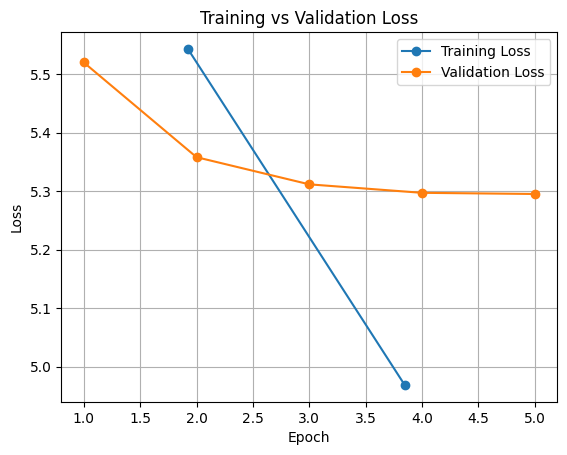

In [ ]:
# plot training vs val loss
plt.figure()

plt.plot(train_epochs, train_loss, marker='o', label="Training Loss")
plt.plot(val_epochs, val_loss, marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

### Evaluate Finetuned Model

In [ ]:
# evaluate finetuned model
results = trainer_p2.evaluate()
results

{'eval_loss': 5.295168876647949,
 'eval_pos_accuracy': 0.7496707769663594,
 'eval_pos_f1_macro': 0.5936281688133742,
 'eval_pos_f1_weighted': 0.7389055246442708,
 'eval_runtime': 5.6583,
 'eval_samples_per_second': 314.228,
 'eval_steps_per_second': 9.897,
 'epoch': 5.0}

### Save Model

In [ ]:
model_multi.save_pretrained("/content/drive/MyDrive/FYP/morphological_analyser_multihead")
tokenizer.save_pretrained("/content/drive/MyDrive/FYP/morphological_analyser_multihead")
# trainer_p2.push_to_hub()
model_multi.push_to_hub("amysp/latin-morphological-analyser-multihead")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ydx156v/model.safetensors:  11%|#         | 47.9MB /  452MB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/amysp/latin-morphological-analyser-multihead/commit/9975c1e78c900d5c292f37d7ecac51fbf88a28da', commit_message='Upload LatinMorphologicalAnalyser', commit_description='', oid='9975c1e78c900d5c292f37d7ecac51fbf88a28da', pr_url=None, repo_url=RepoUrl('https://huggingface.co/amysp/latin-morphological-analyser-multihead', endpoint='https://huggingface.co', repo_type='model', repo_id='amysp/latin-morphological-analyser-multihead'), pr_revision=None, pr_num=None)

## **Evaluation**

In [ ]:
def predict_sentence(sentence_words, model, tokenizer, device,
                     id2label_all, pos_mask_tensor):
    """
    Given a list of Latin words, return a list of dicts — one per word —
    with the predicted POS and all applicable morphological features.

    Features inapplicable for the predicted POS are returned as "—".
    """
    model.eval()
    words_lower = [w.lower() for w in sentence_words]

    encoding = tokenizer(
        words_lower,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        max_length=128,
    ).to(device)

    word_ids = encoding.word_ids(batch_index=0)

    with torch.no_grad():
        output = model(**encoding)

    pos_logits     = output.logits[0]           # (seq_len, num_pos)
    # feature_logits = output.hidden_states[0]    # dict feat → (B, T, num_labels)
    feature_logits = output.feature_logits
    pred_pos_ids   = pos_logits.argmax(dim=-1)  # (seq_len,)

    results, seen = [], set()
    for token_idx, word_id in enumerate(word_ids):
        if word_id is None or word_id in seen:
            continue
        seen.add(word_id)

        pos_idx = pred_pos_ids[token_idx].item()
        pos_str = id2label_all["pos"][pos_idx]
        result  = {"word": sentence_words[word_id], "pos": pos_str}

        for feat_idx, feat in enumerate(FEATURE_ORDER):
            if pos_mask_tensor[pos_idx, feat_idx].item():
                # Corrected line: Access the batch dimension (index 0) first
                pred_idx      = feature_logits[feat][0, token_idx].argmax().item()
                result[feat]  = id2label_all[feat][pred_idx]
            else:
                result[feat] = "—"

        results.append(result)
    return results

In [ ]:
# Example:
words = "in principio erat verbum".split()
for r in predict_sentence(words, model_multi, tokenizer, device,
                           id2label_all, pos_mask_tensor):
    print(r)

{'word': 'in', 'pos': 'R-', 'person': '—', 'number': '—', 'tense': '—', 'mood': '—', 'voice': '—', 'gender': '—', 'case': '—', 'degree': '—'}
{'word': 'principio', 'pos': 'Nb', 'person': '—', 'number': 'Sing', 'tense': '—', 'mood': '—', 'voice': '—', 'gender': 'Masc', 'case': 'Abl', 'degree': '—'}
{'word': 'erat', 'pos': 'V-', 'person': '3', 'number': 'Sing', 'tense': 'Imp', 'mood': 'Ind', 'voice': 'Act', 'gender': '—', 'case': '—', 'degree': '—'}
{'word': 'verbum', 'pos': 'Nb', 'person': '—', 'number': 'Sing', 'tense': '—', 'mood': '—', 'voice': '—', 'gender': 'Masc', 'case': 'Nom', 'degree': '—'}


In [ ]:
def evaluate_all_features(model, dataset, tokenizer, device,
                           label2id_all, id2label_all, pos_mask_tensor,
                           batch_size=32):
    """
    Runs inference over the full dataset and produces a classification
    report for every morphological feature separately.
    """
    from torch.utils.data import DataLoader

    model.eval()

    # We need to run our own DataLoader since Trainer only returns pos_logits
    feat_true = {feat: [] for feat in ALL_FEATS}
    feat_pred = {feat: [] for feat in ALL_FEATS}

    loader = DataLoader(
        dataset.with_format("torch"),
        batch_size=batch_size,
        collate_fn=data_collator_multi,
    )

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            output = model(
                input_ids      = batch["input_ids"],
                attention_mask = batch["attention_mask"],
            )

        pos_logits     = output.logits                 # (B, T, num_pos)
        # feature_logits = output.hidden_states[0]       # dict feat → (B, T, num_labels)
        feature_logits = output.feature_logits
        pred_pos       = pos_logits.argmax(dim=-1)     # (B, T)
        true_pos       = batch["labels_pos"]           # (B, T)

        valid = true_pos != IGNORE_INDEX               # (B, T)

        # Collect POS
        feat_true["pos"].extend(true_pos[valid].cpu().tolist())
        feat_pred["pos"].extend(pred_pos[valid].cpu().tolist())

        # Collect other features
        for feat_idx, feat in enumerate(FEATURE_ORDER):
            true_feat = batch[f"labels_{feat}"]        # (B, T)

            # Applicable = valid token AND feature is active for its true POS
            pos_clamp   = true_pos.clone()
            pos_clamp[~valid] = 0
            applicable  = pos_mask_tensor[pos_clamp, feat_idx] & valid

            if applicable.any():
                pred_feat = feature_logits[feat].argmax(dim=-1)
                feat_true[feat].extend(true_feat[applicable].cpu().tolist())
                feat_pred[feat].extend(pred_feat[applicable].cpu().tolist())

    # Print reports
    for feat in ALL_FEATS:
        if not feat_true[feat]:
            continue
        num_labels  = len(id2label_all[feat])
        print(f"\n{'='*50}")
        print(f"Feature: {feat.upper()}")
        print(f"{'='*50}")
        print(classification_report(
            feat_true[feat],
            feat_pred[feat],
            labels      = list(range(num_labels)),
            target_names= [id2label_all[feat][i] for i in range(num_labels)],
            zero_division= 0,
        ))

In [ ]:
# Run evaluation:
evaluate_all_features(model_multi, test_ds, tokenizer, device,
                      label2id_all, id2label_all, pos_mask_tensor)


Feature: POS
              precision    recall  f1-score   support

          A-       0.74      0.24      0.37       671
          C-       0.97      0.98      0.98      1335
          Df       0.85      0.71      0.78      1472
          Dq       0.88      0.19      0.31        74
          Du       0.79      0.56      0.65        66
          F-       0.00      0.00      0.00         0
          G-       0.92      0.86      0.89       517
          I-       0.74      0.23      0.35        74
          Ma       0.92      0.43      0.59       158
          Mo       0.67      0.17      0.27        35
          Nb       0.57      0.78      0.66      3159
          Ne       0.61      0.26      0.37       629
          Pc       0.00      0.00      0.00         1
          Pd       0.95      0.58      0.72       500
          Pi       0.87      0.82      0.85        90
          Pk       1.00      0.98      0.99        42
          Pp       0.94      0.83      0.88      1101
          Pr 

## finding a threshold

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

%matplotlib inline

In [ ]:
# COLLECT PREDICTIONS WITH CONFIDENCE SCORES

# want to know:

# for each prediction the model makes
# -> (a) what was its confidence
# -> (b) was it right?

# (confidence, correct?) pairs

# helps answer questions like; when the model says its 90% confident
# is it actually right 90% of the time

# helps with threshold selections


def collect_predictions_with_confidence(
    model, dataset, tokenizer, device,
    data_collator, id2label_all, pos_mask_tensor,
    feature_order, all_feats, ignore_index=-100,
    batch_size=32
):
    """
    Run inference on the full dataset and collect, for every valid token
    and every applicable feature:
      - the predicted label
      - the true label
      - the confidence (max softmax probability)
      - the full probability distribution (for deeper analysis)

    Returns a dict keyed by feature name, each containing parallel lists.
    """
    model.eval()

    # Storage: one entry per feature
    results = {
        feat: {
            "true_labels": [],
            "pred_labels": [],
            "confidences": [],     # max softmax prob for the predicted class
            "correct": [],         # boolean: was the prediction correct?
            "entropy": [],         # entropy of the distribution (uncertainty)
        }
        for feat in all_feats
    }

    loader = DataLoader(
        dataset.with_format("torch"),
        batch_size=batch_size,
        collate_fn=data_collator,
    )

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        with torch.no_grad():
            output = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
            )

        # ── POS ────────────────────────────────────────────────────────
        pos_logits = output.logits                          # (B, T, num_pos)
        pos_probs = F.softmax(pos_logits, dim=-1)           # (B, T, num_pos)
        pos_conf, pos_pred = pos_probs.max(dim=-1)          # (B, T) each
        true_pos = batch["labels_pos"]                      # (B, T)
        valid = true_pos != ignore_index                    # (B, T)

        # Collect POS results
        if valid.any():
            t = true_pos[valid].cpu()
            p = pos_pred[valid].cpu()
            c = pos_conf[valid].cpu()

            # Entropy: -sum(p * log(p)), measures how "spread out" the distribution is
            pos_ent = -(pos_probs[valid] * (pos_probs[valid] + 1e-10).log()).sum(dim=-1).cpu()

            results["pos"]["true_labels"].extend(t.tolist())
            results["pos"]["pred_labels"].extend(p.tolist())
            results["pos"]["confidences"].extend(c.tolist())
            results["pos"]["correct"].extend((t == p).tolist())
            results["pos"]["entropy"].extend(pos_ent.tolist())

        # ── Feature heads ──────────────────────────────────────────────
        feature_logits = output.feature_logits

        for feat_idx, feat in enumerate(feature_order):
            true_feat = batch[f"labels_{feat}"]             # (B, T)

            # Only evaluate on tokens where this feature is applicable
            pos_clamp = true_pos.clone()
            pos_clamp[~valid] = 0
            applicable = pos_mask_tensor[pos_clamp, feat_idx] & valid

            if not applicable.any():
                continue

            feat_logits_applicable = feature_logits[feat][applicable]   # (N, num_labels)
            feat_probs = F.softmax(feat_logits_applicable, dim=-1)     # (N, num_labels)
            feat_conf, feat_pred = feat_probs.max(dim=-1)              # (N,) each
            feat_true = true_feat[applicable]                          # (N,)

            feat_ent = -(feat_probs * (feat_probs + 1e-10).log()).sum(dim=-1)

            results[feat]["true_labels"].extend(feat_true.cpu().tolist())
            results[feat]["pred_labels"].extend(feat_pred.cpu().tolist())
            results[feat]["confidences"].extend(feat_conf.cpu().tolist())
            results[feat]["correct"].extend((feat_true.cpu() == feat_pred.cpu()).tolist())
            results[feat]["entropy"].extend(feat_ent.cpu().tolist())

    # Convert to numpy for easier analysis
    for feat in results:
        for key in results[feat]:
            results[feat][key] = np.array(results[feat][key])

    return results



In [ ]:
# RUN COLLECTION ON TEST SET

prediction_data = collect_predictions_with_confidence(
    model=model_multi,
    dataset=test_ds,
    tokenizer=tokenizer,
    device=device,
    data_collator=data_collator_multi,
    id2label_all=id2label_all,
    pos_mask_tensor=pos_mask_tensor,
    feature_order=FEATURE_ORDER,
    all_feats=ALL_FEATS,
    ignore_index=IGNORE_INDEX,
    batch_size=32,
)


In [ ]:
# PRINT OVERVIEW STATISTICS

# For each feature:
# - Total predictions: how many tokens had this feature applicable
# - Overall accuracy: how often the model was correct (no threshold)
# - Mean confidence: average max-probability across all predictions
# - Mean confidence when CORRECT vs WRONG



def print_overview(prediction_data, id2label_all, all_feats):
    print(f"{'Feature':<12} {'N':>8} {'Accuracy':>10} {'Mean Conf':>10} "
          f"{'Conf|Correct':>13} {'Conf|Wrong':>11} {'Separation':>11}")
    print("─" * 80)

    for feat in all_feats:
        data = prediction_data[feat]
        if len(data["correct"]) == 0:
            continue

        n = len(data["correct"])
        acc = data["correct"].mean()
        mean_conf = data["confidences"].mean()

        correct_mask = data["correct"].astype(bool)
        wrong_mask = ~correct_mask

        conf_correct = data["confidences"][correct_mask].mean() if correct_mask.any() else 0
        conf_wrong = data["confidences"][wrong_mask].mean() if wrong_mask.any() else 0
        separation = conf_correct - conf_wrong

        print(f"{feat:<12} {n:>8,} {acc:>10.4f} {mean_conf:>10.4f} "
              f"{conf_correct:>13.4f} {conf_wrong:>11.4f} {separation:>11.4f}")




print_overview(prediction_data, id2label_all, ALL_FEATS)


Feature             N   Accuracy  Mean Conf  Conf|Correct  Conf|Wrong  Separation
────────────────────────────────────────────────────────────────────────────────
pos            16,423     0.7552     0.7636        0.8533      0.4868      0.3665
person          4,073     0.7739     0.8111        0.8691      0.6128      0.2562
number         11,542     0.7844     0.7982        0.8414      0.6412      0.2001
tense           4,073     0.7014     0.7229        0.7917      0.5612      0.2305
mood            4,073     0.7992     0.8326        0.8793      0.6464      0.2329
voice           4,073     0.9047     0.9002        0.9106      0.8022      0.1084
gender          7,469     0.7054     0.7226        0.7937      0.5522      0.2415
case            7,469     0.7433     0.7742        0.8482      0.5598      0.2884
degree          2,143     0.8829     0.8888        0.9171      0.6750      0.2421


In [ ]:
# https://medium.com/data-science/introduction-to-reliability-diagrams-for-probability-calibration-ed785b3f5d44
# https://github.com/hollance/reliability-diagrams

# When a model is calibrated, the confidence score should equal the accuracy

# reliability diagram:
# perfectly calibraed model -> diagonal line  (confidence equals accuracye)

# if the model is overcondfident (conf > accuracy) then the threhsold needs
# to be set higher

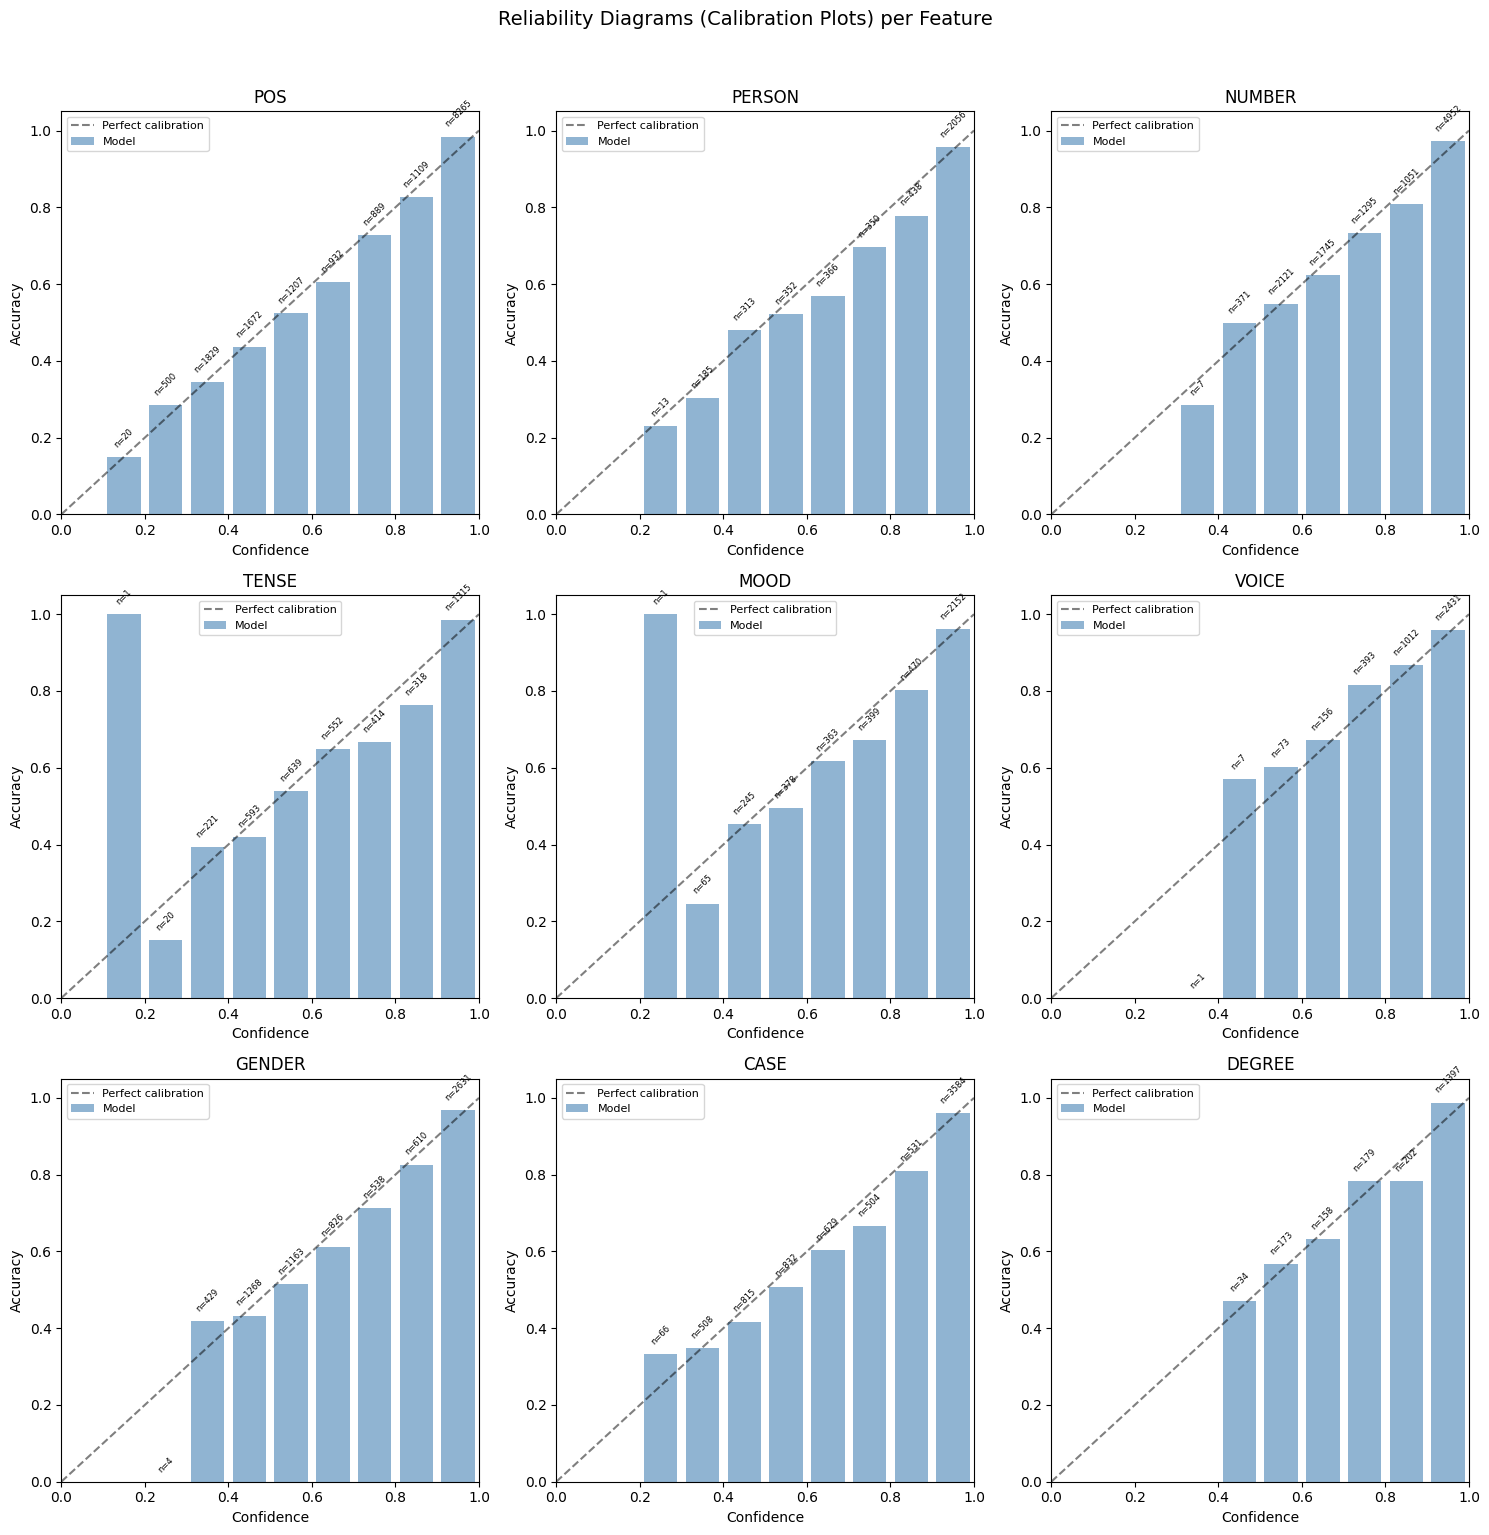

In [ ]:
# reliabiity diagrams

def plot_reliability_diagrams(prediction_data, all_feats, n_bins=10):
    feats_with_data = [f for f in all_feats if len(prediction_data[f]["correct"]) > 0]
    n = len(feats_with_data)
    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for idx, feat in enumerate(feats_with_data):
        ax = axes[idx]
        data = prediction_data[feat]
        confs = data["confidences"]
        correct = data["correct"].astype(float)

        bin_edges = np.linspace(0, 1, n_bins + 1)
        bin_accs = []
        bin_confs = []
        bin_counts = []

        for i in range(n_bins):
            mask = (confs >= bin_edges[i]) & (confs < bin_edges[i + 1])
            if i == n_bins - 1:  # include right edge for last bin
                mask = (confs >= bin_edges[i]) & (confs <= bin_edges[i + 1])
            if mask.sum() > 0:
                bin_accs.append(correct[mask].mean())
                bin_confs.append(confs[mask].mean())
                bin_counts.append(mask.sum())
            else:
                bin_accs.append(0)
                bin_confs.append((bin_edges[i] + bin_edges[i + 1]) / 2)
                bin_counts.append(0)

        bin_centers = [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(n_bins)]

        # Plot calibration
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
        ax.bar(bin_centers, bin_accs, width=1/n_bins * 0.8, alpha=0.6, color='steelblue', label='Model')
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{feat.upper()}')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)

        # Add count annotations
        for i, count in enumerate(bin_counts):
            if count > 0:
                ax.text(bin_centers[i], bin_accs[i] + 0.02, f'n={count}',
                        ha='center', va='bottom', fontsize=6, rotation=45)

    # Hide unused subplots
    for idx in range(len(feats_with_data), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle('Reliability Diagrams (Calibration Plots) per Feature', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()



plot_reliability_diagrams(prediction_data, ALL_FEATS)

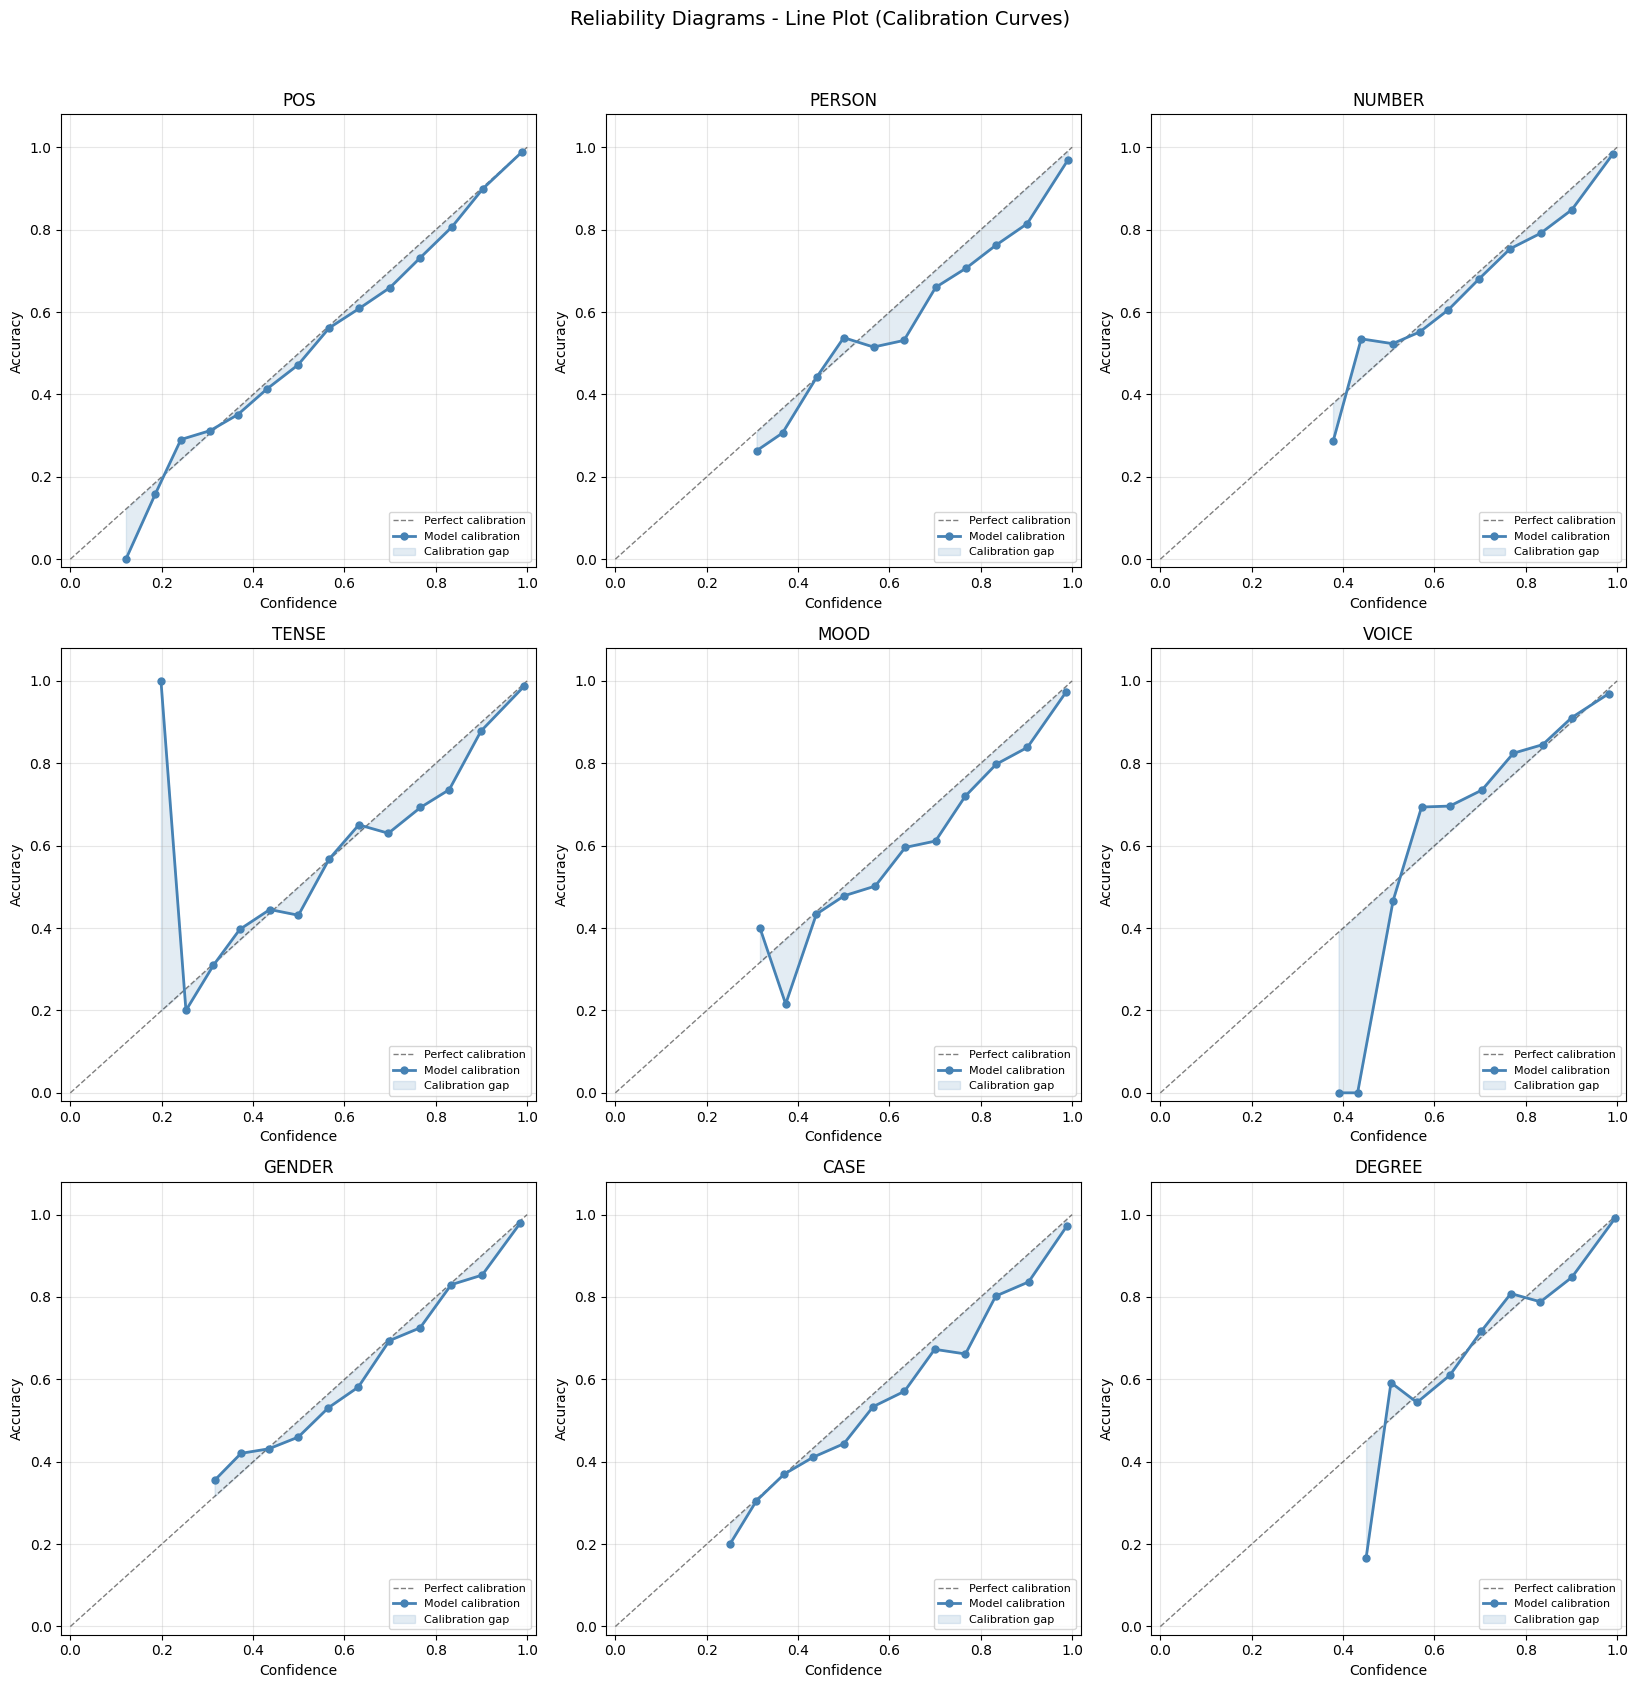

In [ ]:
# reliabiltiy diagram but line instead of bars

# If the blue line is BELOW the diagonal, the model is OVERCONFIDENT
# eg the model is 90 percent confident but it is actually right only 80% of the time

# If the blue line is ABOVE the diagonal, the model is UNDERCONFIDENT
# eg its 70% sure but is actually right 85% of the time


def plot_reliability_diagrams_line(prediction_data, all_feats, n_bins=15):
    """
    Line/curve version of reliability diagrams.
    Shows calibration curves with gap shading and sample count bars.
    """
    feats_with_data = [f for f in all_feats if len(prediction_data[f]["correct"]) > 0]
    n = len(feats_with_data)
    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 5.5 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for idx, feat in enumerate(feats_with_data):
        ax = axes[idx]
        data = prediction_data[feat]
        confs = data["confidences"]
        correct = data["correct"].astype(float)
        total_samples = len(confs)

        bin_edges = np.linspace(0, 1, n_bins + 1)
        bin_centers = []
        bin_accs = []
        bin_mean_confs = []
        bin_counts = []

        for i in range(n_bins):
            if i < n_bins - 1:
                mask = (confs >= bin_edges[i]) & (confs < bin_edges[i + 1])
            else:
                mask = (confs >= bin_edges[i]) & (confs <= bin_edges[i + 1])

            count = mask.sum()
            center = (bin_edges[i] + bin_edges[i + 1]) / 2

            if count > 0:
                bin_centers.append(center)
                bin_accs.append(correct[mask].mean())
                bin_mean_confs.append(confs[mask].mean())
                bin_counts.append(count)
            else:
                bin_centers.append(center)
                bin_accs.append(np.nan)
                bin_mean_confs.append(center)
                bin_counts.append(0)

        bin_centers = np.array(bin_centers)
        bin_accs = np.array(bin_accs)
        bin_mean_confs = np.array(bin_mean_confs)
        bin_counts = np.array(bin_counts)

        # Only plot bins that have data
        valid_mask = ~np.isnan(bin_accs)

        # ── Calibration curve ──────────────────────────────────────────
        # Perfect calibration diagonal
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1, label='Perfect calibration')

        # Model's calibration curve (using mean confidence per bin on x-axis
        # rather than bin center — this is more accurate because bins may
        # not be uniformly filled)
        if valid_mask.any():
            x_vals = bin_mean_confs[valid_mask]
            y_vals = bin_accs[valid_mask]

            ax.plot(x_vals, y_vals, 'o-', color='steelblue', linewidth=2,
                    markersize=5, label='Model calibration', zorder=3)

            # Shade the gap between model and perfect calibration
            ax.fill_between(x_vals, x_vals, y_vals, alpha=0.15, color='steelblue',
                            label='Calibration gap')


        # # ── ECE (Expected Calibration Error) ──────────────────────────
        # # ECE = sum over bins of (count_in_bin / total) * |accuracy - confidence|
        # ece = 0.0
        # for i in range(len(bin_centers)):
        #     if bin_counts[i] > 0 and not np.isnan(bin_accs[i]):
        #         ece += (bin_counts[i] / total_samples) * abs(bin_accs[i] - bin_mean_confs[i])

        # ax.text(0.05, 0.92, f'ECE = {ece:.4f}', transform=ax.transAxes,
        #         fontsize=10, verticalalignment='top',
        #         bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.7))

        # ── Labels and formatting ─────────────────────────────────────
        ax.set_xlabel('Confidence', fontsize=10)
        ax.set_ylabel('Accuracy', fontsize=10)
        ax.set_title(f'{feat.upper()}', fontsize=12)
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.08)
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(True, alpha=0.3)

    for idx in range(len(feats_with_data), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle('Reliability Diagrams - Line Plot (Calibration Curves)',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_reliability_diagrams_line(prediction_data, ALL_FEATS, n_bins=15)

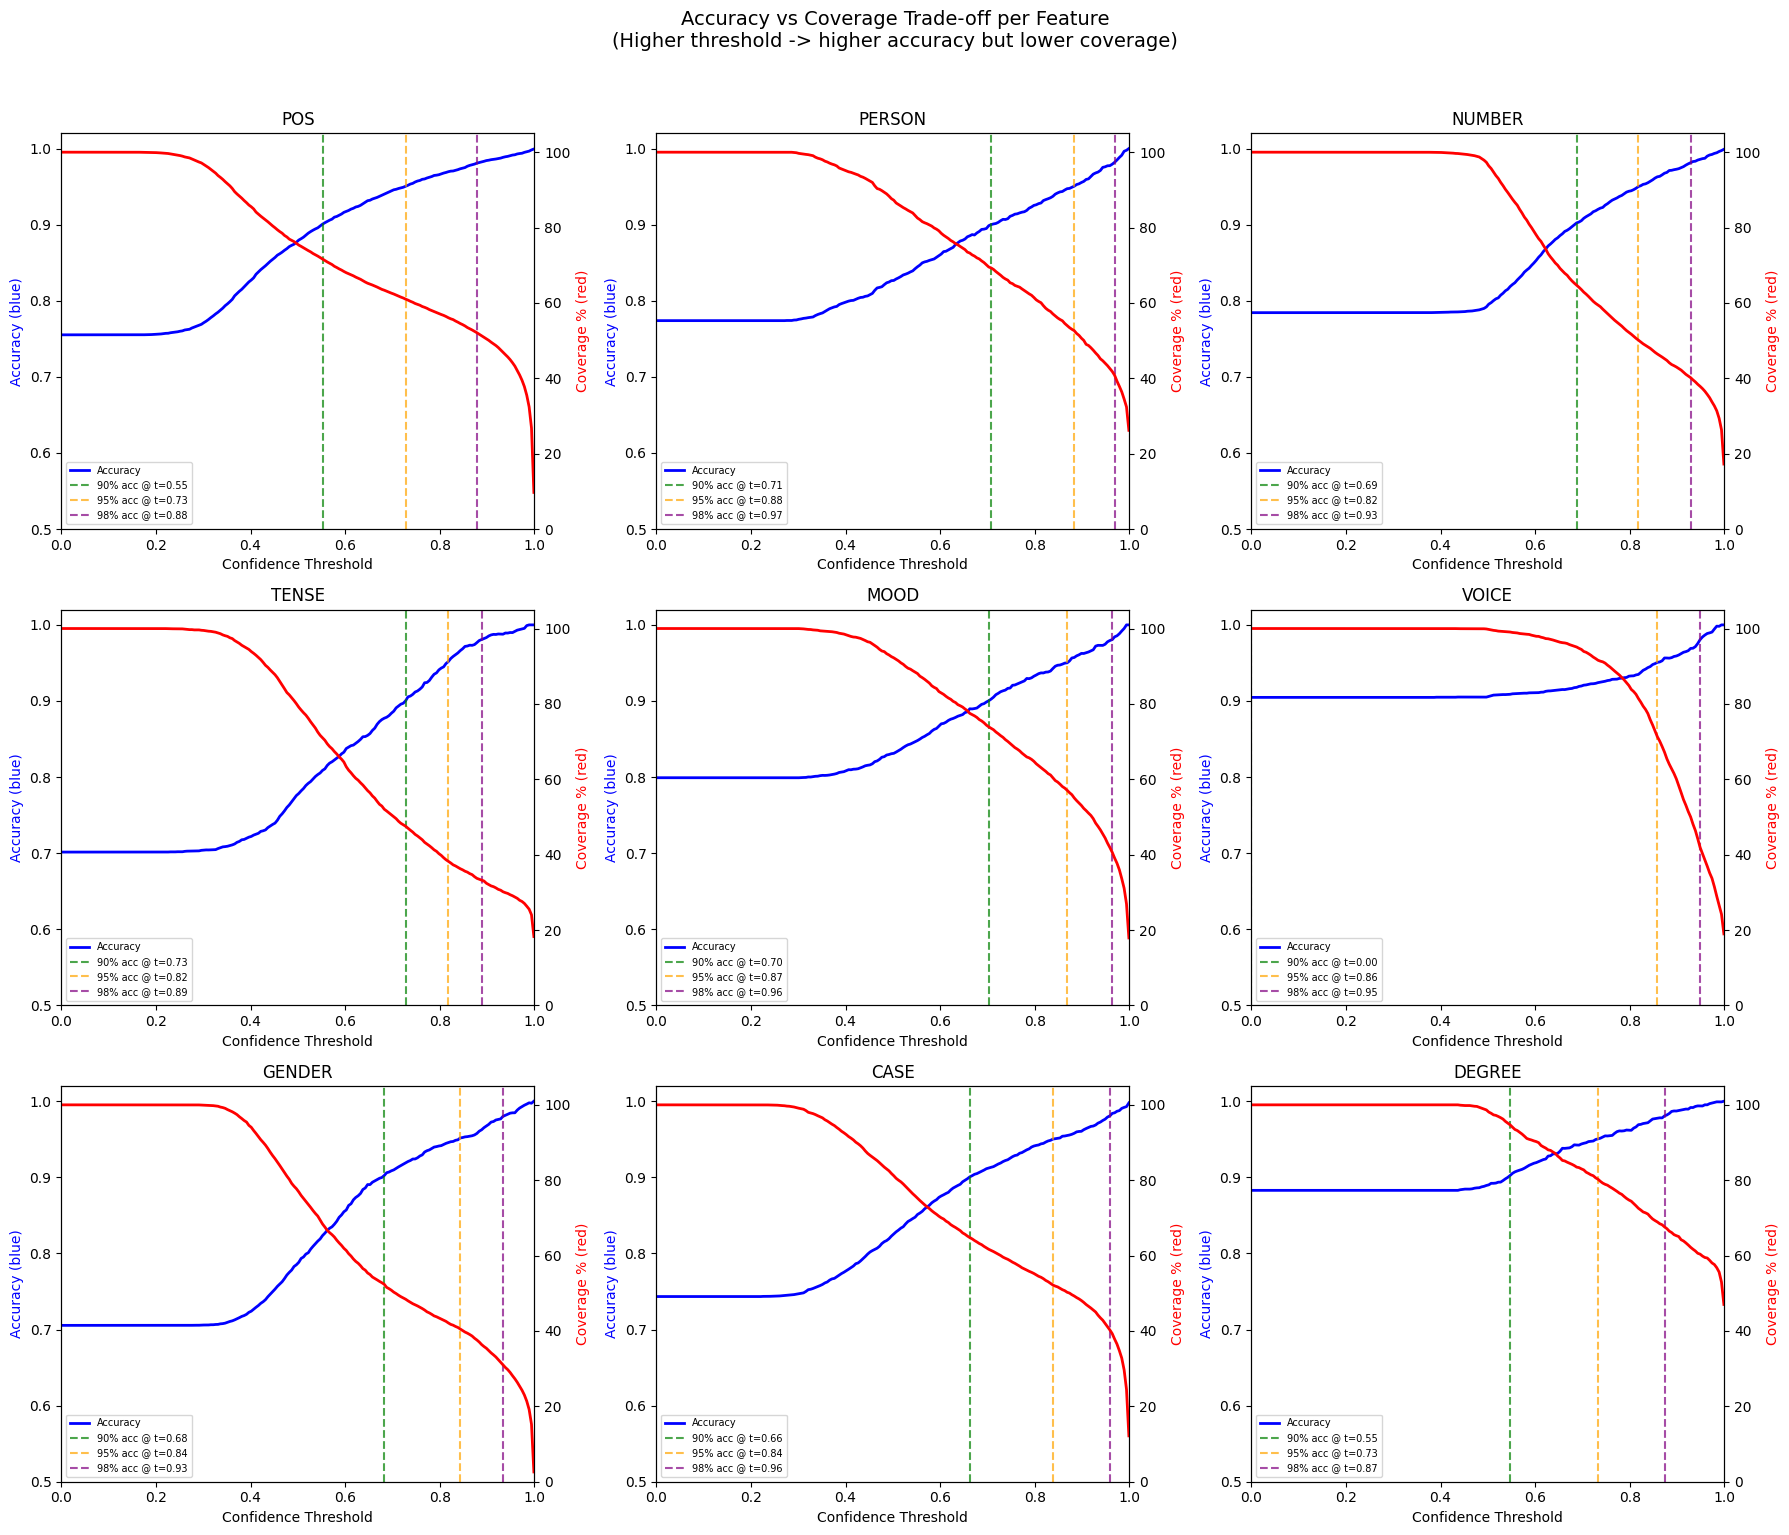

In [ ]:
# accuracy vs coverage tradeoff curbves

# accuracy vs coverage tradeoff
# raising the confidence threhsold
# -> accuracy increases because u only keep predictions the model is sure about
# -> coverage decreases because more predictions use fallback emthod

# want to find where acc is high enoguh where u trust the models output
# and wher coverage is high enough that its not falling back for every word

# x-acis: confidence threshold (predictions below this -> fallback)
# Left Y-axis (blue): accuracy of predictions ABOVE the threshold
# Right Y-axis (red): percentage of predictions that meet the threshold (coverage)
# vertical dashed lines show suggested thresholds at specific accuracy targets

# example, if at threshold=0.85:
# - Accuracy = 98% and Coverage = 70%
# -> The model handles 70% of tokens with 98% accuracy
# -> The remaining 30% go to fallback


def plot_accuracy_coverage_tradeoff(prediction_data, all_feats, accuracy_targets=(0.90, 0.95, 0.98)):
    feats_with_data = [f for f in all_feats if len(prediction_data[f]["correct"]) > 0]
    n = len(feats_with_data)
    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    threshold_results = {}

    for idx, feat in enumerate(feats_with_data):
        ax = axes[idx]
        data = prediction_data[feat]
        confs = data["confidences"]
        correct = data["correct"].astype(float)

        thresholds = np.linspace(0.0, 0.999, 200)
        accuracies = []
        coverages = []

        for t in thresholds:
            mask = confs >= t
            if mask.sum() > 0:
                accuracies.append(correct[mask].mean())
                coverages.append(mask.mean())
            else:
                accuracies.append(1.0)
                coverages.append(0.0)

        accuracies = np.array(accuracies)
        coverages = np.array(coverages)

        # Plot
        ax.plot(thresholds, accuracies, 'b-', linewidth=2, label='Accuracy')
        ax2 = ax.twinx()
        ax2.plot(thresholds, coverages * 100, 'r-', linewidth=2, label='Coverage %')

        # Find thresholds for accuracy targets
        feat_thresholds = {}
        colors = ['green', 'orange', 'purple']
        for ti, target in enumerate(accuracy_targets):
            # Find lowest threshold where accuracy >= target
            candidates = np.where(accuracies >= target)[0]
            if len(candidates) > 0:
                best_idx = candidates[0]  # lowest threshold achieving target
                feat_thresholds[target] = {
                    "threshold": thresholds[best_idx],
                    "accuracy": accuracies[best_idx],
                    "coverage": coverages[best_idx],
                }
                ax.axvline(x=thresholds[best_idx], color=colors[ti], linestyle='--',
                          alpha=0.7, label=f'{target:.0%} acc @ t={thresholds[best_idx]:.2f}')

        threshold_results[feat] = feat_thresholds

        ax.set_xlabel('Confidence Threshold')
        ax.set_ylabel('Accuracy (blue)', color='b')
        ax2.set_ylabel('Coverage % (red)', color='r')
        ax.set_title(f'{feat.upper()}')
        ax.set_xlim(0, 1)
        ax.set_ylim(0.5, 1.02)
        ax2.set_ylim(0, 105)
        ax.legend(fontsize=7, loc='lower left')

    for idx in range(len(feats_with_data), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle('Accuracy vs Coverage Trade-off per Feature\n'
                 '(Higher threshold -> higher accuracy but lower coverage)',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    return threshold_results



threshold_results = plot_accuracy_coverage_tradeoff(prediction_data, ALL_FEATS)


In [ ]:
# RECOMMENDED THRESHOLDS TABLE

# For each feature and accuracy target
# -> What confidence threshold to use
# -> What accuracy you actually achieve
# -> What percentage of tokens the model will handle (coveage)

# different threshold s for different features
# -> per features thresholds

# threshold on the pos first, then if pos passes
# therehsold on each feature


def print_threshold_table(threshold_results, accuracy_targets=(0.90, 0.95, 0.98)):
    print(f"\n")
    print(f"RECOMMENDED THRESHOLDS")

    for target in accuracy_targets:
        print(f"\n{'─'*90}")
        print(f"  Target Accuracy: {target:.0%}")
        print(f"{'─'*90}")
        print(f"  {'Feature':<12} {'Threshold':>10} {'Actual Acc':>12} {'Coverage':>10} {'Fallback %':>12}")
        print(f"  {'─'*58}")

        for feat, thresholds in threshold_results.items():
            if target in thresholds:
                t = thresholds[target]
                print(f"  {feat:<12} {t['threshold']:>10.3f} {t['accuracy']:>12.4f} "
                      f"{t['coverage']:>10.2%} {1 - t['coverage']:>12.2%}")
            else:
                print(f"  {feat:<12} {'N/A':>10} {'—':>12} {'—':>10} {'—':>12}")


print_threshold_table(threshold_results)



RECOMMENDED THRESHOLDS

──────────────────────────────────────────────────────────────────────────────────────────
  Target Accuracy: 90%
──────────────────────────────────────────────────────────────────────────────────────────
  Feature       Threshold   Actual Acc   Coverage   Fallback %
  ──────────────────────────────────────────────────────────
  pos               0.552       0.9007     71.65%       28.35%
  person            0.708       0.9001     69.29%       30.71%
  number            0.688       0.9022     64.70%       35.30%
  tense             0.728       0.9003     47.53%       52.47%
  mood              0.703       0.9003     73.90%       26.10%
  voice             0.000       0.9047    100.00%        0.00%
  gender            0.683       0.9024     52.39%       47.61%
  case              0.663       0.9006     64.79%       35.21%
  degree            0.547       0.9024     94.68%        5.32%

─────────────────────────────────────────────────────────────────────────────

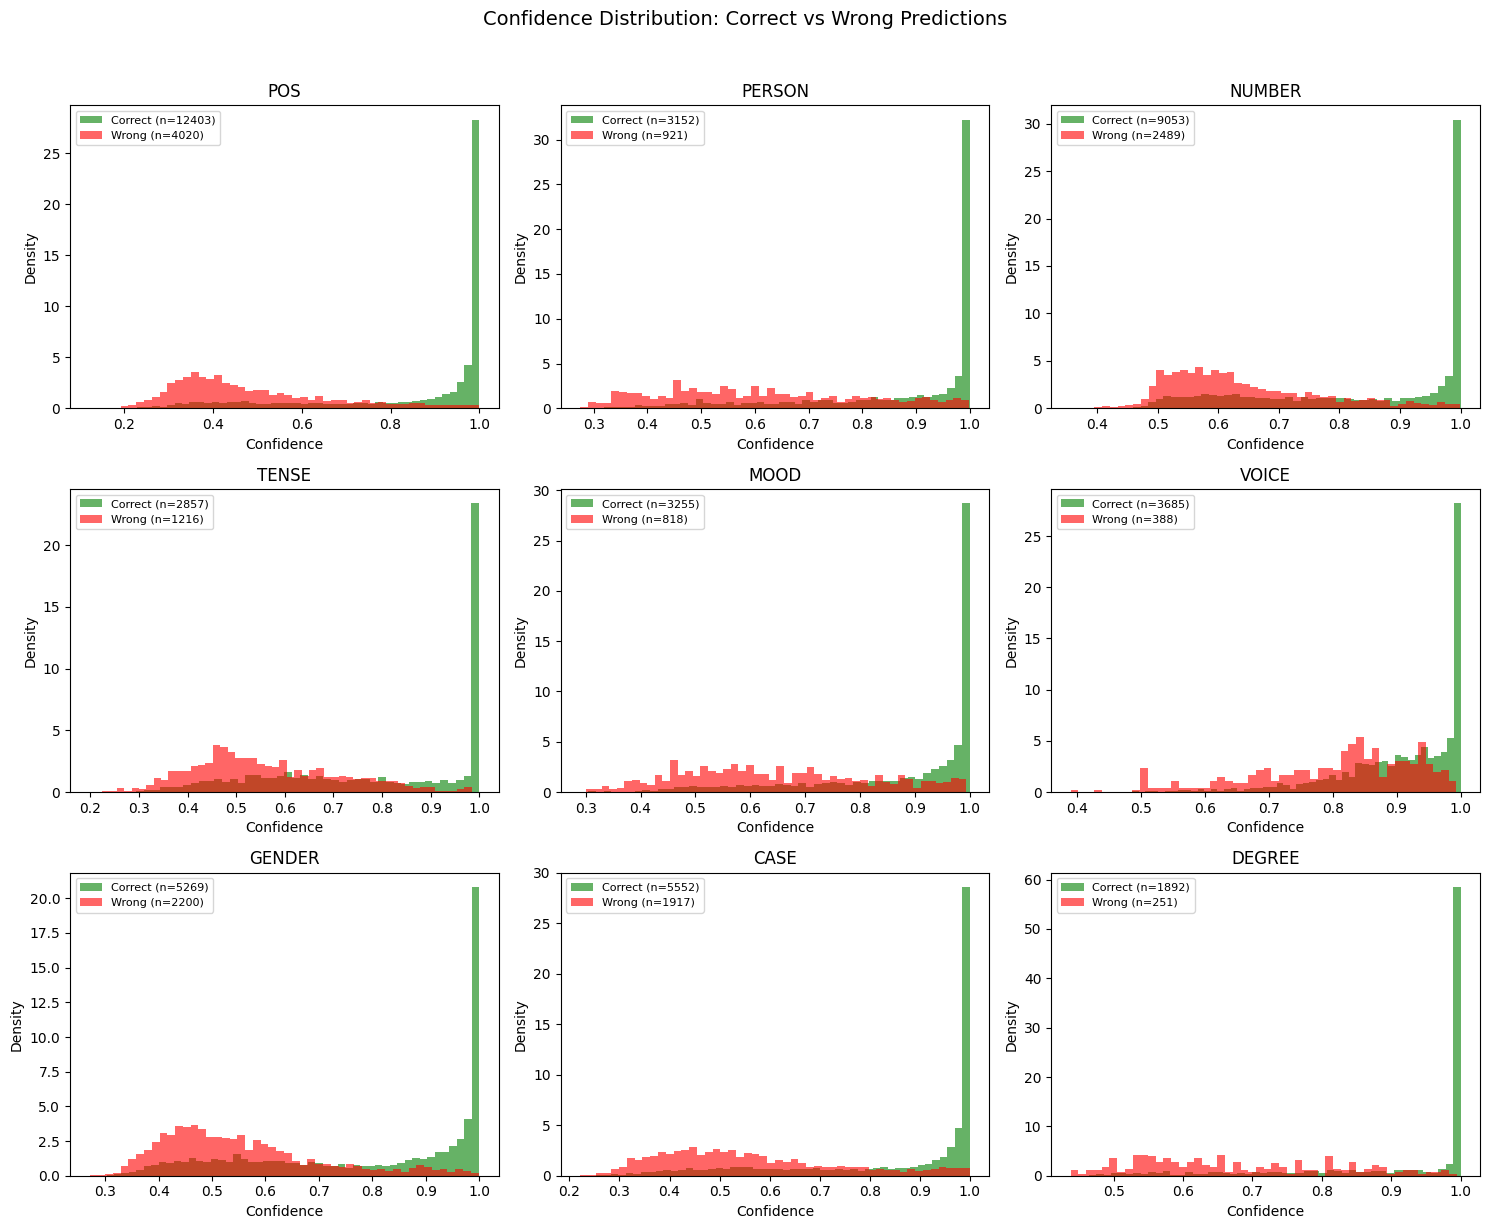

In [ ]:
# confidence distribution plot - correct vs wrong

# shows the distribution of confidence values split
# by whetehr the prediction was corect or wrong

# if the 2 distributsions are well separated
# ie correct predictions -> high conf and wrong -> low conf
# confidence based threhsolding is good and will work very well

# if they overlap a lot then the model is overcinfudent
# very confident but giving wrong predicitons


def plot_confidence_distributions(prediction_data, all_feats):
    feats_with_data = [f for f in all_feats
                       if len(prediction_data[f]["correct"]) > 0
                       and (~prediction_data[f]["correct"].astype(bool)).any()]
    n = len(feats_with_data)
    if n == 0:
        print("No features with both correct and wrong predictions to plot.")
        return

    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for idx, feat in enumerate(feats_with_data):
        ax = axes[idx]
        data = prediction_data[feat]
        correct_mask = data["correct"].astype(bool)

        confs_correct = data["confidences"][correct_mask]
        confs_wrong = data["confidences"][~correct_mask]

        ax.hist(confs_correct, bins=50, alpha=0.6, color='green', label=f'Correct (n={len(confs_correct)})', density=True)
        ax.hist(confs_wrong, bins=50, alpha=0.6, color='red', label=f'Wrong (n={len(confs_wrong)})', density=True)
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Density')
        ax.set_title(f'{feat.upper()}')
        ax.legend(fontsize=8)

    for idx in range(len(feats_with_data), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle('Confidence Distribution: Correct vs Wrong Predictions', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_confidence_distributions(prediction_data, ALL_FEATS)

In [ ]:

# Step 1: Run model on the word

# Step 2: Check POS confidence
# - If POS confidence < pos_threshold -> fall back ENTIRELY
#   (because if POS is wrong, all downstream features are unreliable)
# - If POS confidence >= pos_threshold -> accept POS, proceed to features

# Step 3: For each morphological feature:
# - If feature confidence < feat_threshold -> fall back for THIS feature only
# - If feature confidence >= feat_threshold -> accept prediction

def predict_with_confidence(
    sentence_words, model, tokenizer, device,
    id2label_all, pos_mask_tensor, feature_order,
    thresholds=None,
):
    """
    Predict morphological features with confidence scores and fallback flags.

    Args:
        sentence_words: list of word strings
        model, tokenizer, device: as usual
        id2label_all: label vocabularies
        pos_mask_tensor: POS-feature compatibility mask
        feature_order: list of feature names
        thresholds: dict[feat] -> float threshold, or single float for all.
                    If None, no thresholding (all predictions accepted).

    Returns:
        list of dicts, one per word. Each dict contains:
          - "word": the input word
          - "pos": {"label": str, "confidence": float, "needs_fallback": bool}
          - "person": {"label": str, "confidence": float, "needs_fallback": bool}
          - ... (for each applicable feature)
          - features not applicable for the predicted POS get:
            {"label": "—", "confidence": None, "needs_fallback": False, "applicable": False}
    """
    model.eval()
    words_lower = [w.lower() for w in sentence_words]

    encoding = tokenizer(
        words_lower,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        max_length=128,
    ).to(device)

    word_ids = encoding.word_ids(batch_index=0)

    with torch.no_grad():
        output = model(**encoding)

    pos_logits = output.logits[0]               # (seq_len, num_pos)
    feature_logits = output.feature_logits


    pos_probs = F.softmax(pos_logits, dim=-1)
    pos_conf, pos_pred = pos_probs.max(dim=-1)

    # Determine thresholds
    if thresholds is None:
        thresholds = {}
    elif isinstance(thresholds, (int, float)):
        t = float(thresholds)
        thresholds = {feat: t for feat in ["pos"] + feature_order}

    results = []
    seen = set()

    for token_idx, word_id in enumerate(word_ids):
        if word_id is None or word_id in seen:
            continue
        seen.add(word_id)

        pos_idx = pos_pred[token_idx].item()
        pos_confidence = pos_conf[token_idx].item()
        pos_str = id2label_all["pos"][pos_idx]
        pos_threshold = thresholds.get("pos", 0.0)

        result = {
            "word": sentence_words[word_id],
            "pos": {
                "label": pos_str,
                "confidence": round(pos_confidence, 4),
                "needs_fallback": pos_confidence < pos_threshold,
                "probabilities": {id2label_all["pos"][i]: round(p, 4)
                                  for i, p in enumerate(pos_probs[token_idx].cpu().tolist())
                                  if p > 0.01},  # only show probs > 1%
            },
        }

        for feat_idx, feat in enumerate(feature_order):
            if pos_mask_tensor[pos_idx, feat_idx].item():
                feat_logit = feature_logits[feat][0, token_idx]  # (num_labels,)


                feat_probs = F.softmax(feat_logit, dim=-1)
                feat_conf, feat_pred_idx = feat_probs.max(dim=-1)

                feat_confidence = feat_conf.item()
                feat_threshold = thresholds.get(feat, 0.0)

                result[feat] = {
                    "label": id2label_all[feat][feat_pred_idx.item()],
                    "confidence": round(feat_confidence, 4),
                    "needs_fallback": feat_confidence < feat_threshold,
                    "applicable": True,
                    "probabilities": {id2label_all[feat][i]: round(p, 4)
                                      for i, p in enumerate(feat_probs.cpu().tolist())
                                      if p > 0.01},
                }
            else:
                result[feat] = {
                    "label": "—",
                    "confidence": None,
                    "needs_fallback": False,
                    "applicable": False,
                }

        results.append(result)

    return results


# Thresholds for target Accuracy 98%:
# pos               0.879
# person            0.969
# number            0.929
# tense             0.889
# mood              0.964
# voice             0.949
# gender            0.934
# case              0.959
# degree            0.873


# Define thresholds from the analysis above
my_thresholds = {
    "pos": 0.879,
    "person": 0.969,
    "number": 0.929,
    "tense": 0.889,
    "mood": 0.964,
    "voice": 0.949 ,
    "gender": 0.934 ,
    "case": 0.959 ,
    "degree": 0.873,
}



In [ ]:
words = "in principio erat verbum".split()  # in the beginning was the Word
results = predict_with_confidence(
    words, model_multi, tokenizer, device,
    id2label_all, pos_mask_tensor, FEATURE_ORDER,
    thresholds=my_thresholds,
)

for r in results:
    print(f"\n{'-'*60}")
    print(f"Word: {r['word']}")
    print(f"  POS: {r['pos']['label']} (conf={r['pos']['confidence']:.3f}, "
          f"fallback={r['pos']['needs_fallback']})")
    for feat in FEATURE_ORDER:
        info = r[feat]
        if info['applicable']:
            print(f"  {feat:<8}: {info['label']} (conf={info['confidence']:.3f}, "
                  f"fallback={info['needs_fallback']})")




------------------------------------------------------------
Word: in
  POS: R- (conf=1.000, fallback=False)

------------------------------------------------------------
Word: principio
  POS: Nb (conf=0.792, fallback=True)
  number  : Sing (conf=0.688, fallback=True)
  gender  : Masc (conf=0.344, fallback=True)
  case    : Abl (conf=0.947, fallback=True)

------------------------------------------------------------
Word: erat
  POS: V- (conf=0.995, fallback=False)
  person  : 3 (conf=1.000, fallback=False)
  number  : Sing (conf=1.000, fallback=False)
  tense   : Imp (conf=0.999, fallback=False)
  mood    : Ind (conf=0.999, fallback=False)
  voice   : Act (conf=1.000, fallback=False)

------------------------------------------------------------
Word: verbum
  POS: Nb (conf=0.570, fallback=True)
  number  : Sing (conf=0.872, fallback=True)
  gender  : Masc (conf=0.632, fallback=True)
  case    : Nom (conf=0.856, fallback=True)


In [ ]:
words = "amicus certus in re incerta".split()  # a sure friend in an unsure matter
results = predict_with_confidence(
    words, model_multi, tokenizer, device,
    id2label_all, pos_mask_tensor, FEATURE_ORDER,
    thresholds=my_thresholds,
)

for r in results:
    print(f"\n{'-'*60}")
    print(f"Word: {r['word']}")
    print(f"  POS: {r['pos']['label']} (conf={r['pos']['confidence']:.3f}, "
          f"fallback={r['pos']['needs_fallback']})")
    for feat in FEATURE_ORDER:
        info = r[feat]
        if info['applicable']:
            print(f"  {feat:<8}: {info['label']} (conf={info['confidence']:.3f}, "
                  f"fallback={info['needs_fallback']})")



------------------------------------------------------------
Word: amicus
  POS: V- (conf=0.491, fallback=True)
  person  : 2 (conf=0.493, fallback=True)
  number  : Sing (conf=0.551, fallback=True)
  tense   : Pres (conf=0.566, fallback=True)
  mood    : Ind (conf=0.593, fallback=True)
  voice   : Act (conf=0.874, fallback=True)

------------------------------------------------------------
Word: certus
  POS: V- (conf=0.444, fallback=True)
  person  : 2 (conf=0.395, fallback=True)
  number  : Sing (conf=0.587, fallback=True)
  tense   : Pres (conf=0.575, fallback=True)
  mood    : Ind (conf=0.696, fallback=True)
  voice   : Act (conf=0.780, fallback=True)

------------------------------------------------------------
Word: in
  POS: R- (conf=1.000, fallback=False)

------------------------------------------------------------
Word: re
  POS: Nb (conf=0.908, fallback=False)
  number  : Sing (conf=0.986, fallback=False)
  gender  : Fem (conf=0.542, fallback=True)
  case    : Abl (conf=0.

In [ ]:
words = "in absentia lucis, tenebrae vincunt".split() # in the absence of light, darkness prevails
results = predict_with_confidence(
    words, model_multi, tokenizer, device,
    id2label_all, pos_mask_tensor, FEATURE_ORDER,
    thresholds=my_thresholds,
)

for r in results:
    print(f"\n{'-'*60}")
    print(f"Word: {r['word']}")
    print(f"  POS: {r['pos']['label']} (conf={r['pos']['confidence']:.3f}, "
          f"fallback={r['pos']['needs_fallback']})")
    for feat in FEATURE_ORDER:
        info = r[feat]
        if info['applicable']:
            print(f"  {feat:<8}: {info['label']} (conf={info['confidence']:.3f}, "
                  f"fallback={info['needs_fallback']})")



------------------------------------------------------------
Word: in
  POS: R- (conf=1.000, fallback=False)

------------------------------------------------------------
Word: absentia
  POS: Nb (conf=0.921, fallback=False)
  number  : Sing (conf=0.955, fallback=False)
  gender  : Fem (conf=0.989, fallback=False)
  case    : Abl (conf=0.998, fallback=False)

------------------------------------------------------------
Word: lucis,
  POS: Df (conf=0.358, fallback=True)
  degree  : None (conf=0.946, fallback=False)

------------------------------------------------------------
Word: tenebrae
  POS: Nb (conf=0.316, fallback=True)
  number  : Sing (conf=0.778, fallback=True)
  gender  : Masc (conf=0.447, fallback=True)
  case    : Acc (conf=0.247, fallback=True)

------------------------------------------------------------
Word: vincunt
  POS: Nb (conf=0.373, fallback=True)
  number  : Sing (conf=0.527, fallback=True)
  gender  : Fem (conf=0.396, fallback=True)
  case    : Gen (conf=0.367